In [78]:
print("                GROUP K MEMBERS ")
print()
print("1)   NAMUJUZI RITAH ----------- 24/U/09292/EVE -------- 2400709292")
print()

print("2)   TAGOOLE MUGWA DAVID ----------- 24/U/11413/EVE -------- 2400711413")
print()

print("3)   KASIBANTE TAUFIC LARRY ----------- 24/U/05379/EVE -------- 2400705379")
print()

print("4)   MUHINDO JULIANAH ALINETHU ----------- 24/U/07104/EVE -------- 2400707104")
print()

print("5)   NASSUUNA IVY JOSEPHINE ----------- 24/U/09891/PS -------- 2400709891")
print()

                GROUP K MEMBERS 

1)   NAMUJUZI RITAH ----------- 24/U/09292/EVE -------- 2400709292

2)   TAGOOLE MUGWA DAVID ----------- 24/U/11413/EVE -------- 2400711413

3)   KASIBANTE TAUFIC LARRY ----------- 24/U/05379/EVE -------- 2400705379

4)   MUHINDO JULIANAH ALINETHU ----------- 24/U/07104/EVE -------- 2400707104

5)   NASSUUNA IVY JOSEPHINE ----------- 24/U/09891/PS -------- 2400709891



# Sentiment Analysis Project With A Domain Shift
## 1. Project Overview

Sentiment analysis is the task of automatically detecting whether a piece of text expresses 
a Positive, Negative, or Neutral opinion. While models can learn to do this well on the kind 
of data they were trained on, they often struggle when the writing style changes this is 
known as **Domain Shift**.

In this project, we train our models entirely on social media text from Twitter, then test 
them on three completely different types of real world text that students interact with daily: 
Gmail messages, WhatsApp chats, and Google Play Store app reviews. None of this test data 
was seen during training which makes it a true test of how well our models can adapt.

To handle this challenge, we build a **stacking ensemble** , a system where 10 different 
models each make a prediction, and a final model (XGBoost) learns which of them to trust 
depending on the situation.

---

### The Data We Are Working With

**Training Data — Social Media (Twitter):**
| Dataset | Rows | Source |
|---|---|---|
| sentimentdataset.csv | 732 | 
| Tweets.csv | 14,640 | 
| twitterdataset.csv | 74,000+ | 
| **Total after cleaning** | **67,080** | 

**Test Data — Real-World Student Domains:**
| Dataset | Rows | How It Was Labelled |
|---|---|---|
| Gmail messages | 348 | Manually labelled by the team |
| WhatsApp messages | 318 | Manually labelled by the team |
| Google Play App Reviews | 292 | Manually labelled by the team |
| **Total test examples** | **958** | Across 3 real-world domains |

---


### The 10 Models We Used

We trained 10 different models, each approaching the text in a different way. 
Together they form our ensemble:

| # | Model | Type |
|---|---|---|
| 1 | Naive Bayes | Classical ML |
| 2 | Logistic Regression | Classical ML |
| 3 | Support Vector Machine | Classical ML |
| 4 | Random Forest | Classical ML |
| 5 | Multi-Layer Perceptron | Neural Network |
| 6 | Convolutional Neural Network | Deep Learning |
| 7 | Long Short-Term Memory (LSTM) | Deep Learning |
| 8 | Bidirectional LSTM | Deep Learning |
| 9 | Bidirectional GRU | Deep Learning |
| 10 | BERT( DistilBERT ) | Transformer |

The predictions from all 10 models are passed to an **XGBoost meta-learner** 
which makes the final decision — giving us 11 models in total.

### Objectives

1. **To preprocess and combine** three separate Twitter datasets into one clean, 
   balanced training set with consistent Positive, Negative, and Neutral labels.

2. **To determine how well** models trained on Twitter generalise to text they 
   have never seen before specifically Gmail, WhatsApp, and app reviews.

3. **To build a stacking ensemble** of 10 models that produces stronger, more 
   reliable predictions than any single model on its own.

4. **To explain** why the model labels certain messages as Negative using SHAP 
   and LIME  so the predictions are not just a black box.

## 2. Importing the necessary Libraries

This cell imports all the libraries needed across the entire notebook. One important thing 
happening here is the GPU memory configuration. We manually cap TensorFlow's GPU 
usage at 4096MB (4GB). This is necessary because both TensorFlow and PyTorch run 
in the same notebook and will compete for the same GPU memory on Kaggle's servers. 
Without this limit, TensorFlow would claim all available GPU memory leaving 
nothing for PyTorch when DistilBERT starts training, causing an out-of-memory crash. 
By capping TensorFlow, we ensure both frameworks can run side by side without 
interfering with each other. We also set a fixed random seed across all libraries 
so that results are reproducible every time the notebook runs.

In [80]:
!pip install wordcloud -q
import pandas as pd
import numpy as np
import os
import re
import random
import gc
import zipfile
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from lime.lime_text import LimeTextExplainer


import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SpatialDropout1D, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, GRU, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import xgboost as xgb
from lime.lime_text import LimeTextExplainer
from matplotlib.patches import FancyBboxPatch
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

from wordcloud import WordCloud
import shap



sns.set_theme(style="whitegrid", palette="muted")
gpus = tf.config.list_physical_devices('GPU')
if gpus: 
    try: tf.config.set_logical_device_configuration(gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=4096)])
    except RuntimeError as e: print(e)
SEED = 42
def seed_everything(seed=42):
    random.seed(seed) 
    os.environ['PYTHONHASHSEED'] = str(seed) 
    np.random.seed(seed)
    tf.random.set_seed(seed) 
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed)
seed_everything(SEED) 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 3. Data Loading

This section handles the loading of data at different stages of the notebook: from raw source files for cleaning, to processed datasets for model training and evaluation.

In [ ]:



df_sentiment = pd.read_csv('/kaggle/input/datasets/tagooledavid256/last-rider/sentimentdataset.csv')
df_tweets = pd.read_csv('/kaggle/input/datasets/tagooledavid256/last-rider/Tweets.csv')
df_twitterdataset = pd.read_csv('/kaggle/input/datasets/tagooledavid256/last-rider/twitterdataset.csv', header=None)



df_twitterdataset.columns  = ["id",'topic',"sentiment","text"]




df_gmail_raw = pd.read_csv("/kaggle/input/datasets/tagooledavid256/last-rider/gmail_raw.csv")
df_whatsapp_raw = pd.read_csv("/kaggle/input/datasets/tagooledavid256/last-rider/whatsapp_raw.csv")
df_app_reviews_raw = pd.read_csv("/kaggle/input/datasets/tagooledavid256/last-rider/app_reviews_raw.csv")




train_df = pd.read_csv('/kaggle/input/datasets/tagooledavid256/last-rider/processed_training_dataset.csv').dropna()
val_df = pd.read_csv('/kaggle/input/datasets/tagooledavid256/last-rider/processed_validation_datset.csv').dropna()



train_df = pd.concat([train_df, val_df]).reset_index(drop=True)


df_gmail = pd.read_csv("/kaggle/input/datasets/tagooledavid256/last-rider/gmail_test_data.csv")
df_whatsapp = pd.read_csv("/kaggle/input/datasets/tagooledavid256/last-rider/whatsapp_test_data.csv")
df_app_reviews = pd.read_csv("/kaggle/input/datasets/tagooledavid256/last-rider/labelled_app_reviews_test.csv")


print("Done with data loading...")

Done with data loading...


## 4. Exploratory Data Analysis (EDA)

## 4.1 EDA for Training Dataset (Raw)

### Shape of the data

In [82]:
print("      Data Loaded")
print(f"sentimentdataset.csv  → {df_sentiment.shape[0]} rows, {df_sentiment.shape[1]} columns")
print(f"Tweets.csv            → {df_tweets.shape[0]} rows, {df_tweets.shape[1]} columns")
print(f"twitterdataset.csv    → {df_twitterdataset.shape[0]} rows, {df_twitterdataset.shape[1]} columns")


      Data Loaded
sentimentdataset.csv  → 732 rows, 15 columns
Tweets.csv            → 14640 rows, 15 columns
twitterdataset.csv    → 74682 rows, 4 columns


**Insight**: We loaded three datasets for training. `sentimentdataset.csv` (732 rows) and `Tweets.csv` (14,640 rows) have many extra features (15 columns). The biggest dataset, `twitterdataset.csv`, has over 74,000 rows but only 4 columns. We have nearly 90,000 examples to train our model on, but we need to drop the extra columns and just keep the text and sentiment labels to merge them easily.

### Viewing the first three rows

In [83]:
display("    Sentiment Dataset ")
display(df_sentiment.head(3))

display("    Tweets Dataset    ")
display(df_tweets.head(3))

display("    Twitter Dataset    ")
display(df_twitterdataset.head(3))

'    Sentiment Dataset '

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15


'    Tweets Dataset    '

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


'    Twitter Dataset    '

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...


**Insight**: Looking at the first few rows shows that the column names don't match. For example, the labels are called `Sentiment` in one file but `airline_sentiment` in another. We need to rename these columns so they match before we can combine the datasets.

### Dataset Summaries (Info and Desccribe)

In [84]:
print("    Info for sentimentdataset.csv    ")
df_sentiment.info()
print()
print("     Describe for sentimentdataset.csv    ")
display(df_sentiment.describe(include='all'))

print()
print()
print("     Info for Tweets.csv     ")
df_tweets.info()
print()
print("     Describe for Tweets.csv    ")
display(df_tweets.describe(include='all'))


print()
print()
print("      Info for twitterdataset.csv    ")
df_twitterdataset.info()
print()
print("     Describe for twitterdataset.csv    ")
display(df_twitterdataset.describe(include='all'))

    Info for sentimentdataset.csv    
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB

     Describe for sentimentdataset.csv    


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
count,732.000000,732.000000,732,732,732,732,732,732,732.000000,732.000000,732,732.000000,732.000000,732.000000,732.000000
unique,NaN,NaN,707,279,683,685,4,697,NaN,NaN,115,NaN,NaN,NaN,NaN
top,NaN,NaN,"A compassionate rain, tears of empathy fallin...",Positive,2019-04-05 17:30:00,WinterWarmth,Instagram,#Hopeful #SeedsOfOptimism,NaN,NaN,USA,NaN,NaN,NaN,NaN
freq,NaN,NaN,3,44,3,3,258,3,NaN,NaN,59,NaN,NaN,NaN,NaN
mean,366.464481,369.740437,NaN,NaN,NaN,NaN,NaN,NaN,21.508197,42.901639,NaN,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,NaN,NaN,NaN,NaN,NaN,NaN,7.061286,14.089848,NaN,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,10.000000,NaN,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,NaN,NaN,NaN,NaN,NaN,NaN,17.750000,34.750000,NaN,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,NaN,NaN,NaN,NaN,NaN,NaN,22.000000,43.000000,NaN,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,50.000000,NaN,2023.000000,9.000000,22.000000,19.000000




     Info for Tweets.csv     
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created               

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
count,1.464000e+04,14640,14640.000000,9178,10522.000000,14640,40,14640,32,14640.000000,14640,1019,14640,9907,9820
unique,NaN,3,NaN,10,NaN,6,3,7701,13,NaN,14427,832,14247,3081,85
top,NaN,negative,NaN,Customer Service Issue,NaN,United,negative,JetBlueNews,Customer Service Issue,NaN,@united thanks,"[0.0, 0.0]",2015-02-24 09:54:34 -0800,"Boston, MA",Eastern Time (US & Canada)
freq,NaN,9178,NaN,2910,NaN,3822,32,63,12,NaN,6,164,5,157,3744
mean,5.692184e+17,NaN,0.900169,NaN,0.638298,NaN,NaN,NaN,NaN,0.082650,NaN,NaN,NaN,NaN,NaN
std,7.791112e+14,NaN,0.162830,NaN,0.330440,NaN,NaN,NaN,NaN,0.745778,NaN,NaN,NaN,NaN,NaN
min,5.675883e+17,NaN,0.335000,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,5.685592e+17,NaN,0.692300,NaN,0.360600,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,5.694779e+17,NaN,1.000000,NaN,0.670600,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
75%,5.698905e+17,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN




      Info for twitterdataset.csv    
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   topic      74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB

     Describe for twitterdataset.csv    


,id,topic,sentiment,text
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,Microsoft,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


**Insight**: The data summaries show that the text features are mostly complete, but there are a lot of extra columns (like dates or user IDs) that our models don't need. We will need to remove these extra features later.

### Columns avaialble in the training dataset

In [85]:

print("sentimentdataset.csv columns:", df_sentiment.columns.tolist())
print()
print("Tweets.csv columns:", df_tweets.columns.tolist())
print()
print("twitterdataset.csv columns:", df_twitterdataset.columns.tolist())
print()


sentimentdataset.csv columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

Tweets.csv columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

twitterdataset.csv columns: ['id', 'topic', 'sentiment', 'text']



**Insight**: By looking at the exact column names, we know exactly which ones to keep. For our models, we only care about the input feature (the text) and the target label (the sentiment). We will drop everything else.

### Checking for null values

In [86]:
print("                Null Values Check")
print("df_sentiment nulls:\n", df_sentiment.isnull().sum())
print()
print()
print("df_tweets nulls:\n", df_tweets.isnull().sum())
print()
print()
print("df_twitterdataset nulls:\n", df_twitterdataset.isnull().sum())
print()


                Null Values Check
df_sentiment nulls:
 Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


df_tweets nulls:
 tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


df_twitterdataset nulls:
 id             0
topic         

**Insight**: The null check shows that `sentimentdataset.csv` is completely clean
no missing values anywhere. `Tweets.csv` has missing values but only in columns we 
are not keeping (like `negativereason` and `tweet_location`), so they are not a 
problem. `twitterdataset.csv` has 686 rows where the text is missing and those will 
be dropped during cleaning.

### Checking for rows where the text is just whitespace 

In [87]:
df_sentiment = df_sentiment[df_sentiment['Text'].str.strip().str.len() > 0]
df_tweets = df_tweets[df_tweets['text'].str.strip().str.len() > 0]
df_twitterdataset = df_twitterdataset[df_twitterdataset['text'].str.strip().str.len() > 0]

### Checking the Class Distribution

In [88]:
print("sentimentdataset.csv distribution")
print(df_sentiment.Sentiment.value_counts())
print()
print()
print("tweets.csv distribution")
print(df_tweets.airline_sentiment.value_counts())
print()
print()
print("twitterdataset.csv distribution")
print(df_twitterdataset.sentiment.value_counts())

sentimentdataset.csv distribution
Sentiment
Positive            44
Joy                 42
Excitement          32
Contentment         14
Happy               14
                    ..
Loneliness           1
Anxiety              1
Renewed Effort       1
Miscalculation       1
Challenge            1
Name: count, Length: 279, dtype: int64


tweets.csv distribution
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


twitterdataset.csv distribution
sentiment
Negative      22312
Positive      20619
Neutral       18051
Irrelevant    12842
Name: count, dtype: int64


**Insight**: The class distribution shows that our data is imbalanced. For example, some datasets have way more 'Positive' or 'Negative' labels than others. Also, we have messy labels like 'Irrelevant'. To train the model properly, we need to map all these different labels into just three clean categories: Positive, Negative, and Neutral.

## 4.2 EDA for the Test Data (Raw)

### Viewing first few rows of the data

In [89]:
display("     Gmail Raw")
display(df_gmail_raw.head(3))
print()
print()


display("      WhatsApp Raw")
display(df_whatsapp_raw.head(3))
print()
print()


display("    App Reviews Raw")
display(df_app_reviews_raw.head(3))

'     Gmail Raw'

,email_id,sender,subject,text,timestamp,priority,meta_data,sentiment
0,MSG_0000,user_540@example.com,RE: GitHub: Security ale...,@user GitHub: Security alert - A new SSH key w...,2026-05-16 08:00:00,Low,id=4133;host=gmail-srv-3,Neutral
1,MSG_0001,user_451@example.com,RE: Vultr: Monthly invoi...,!!! Vultr: Monthly invoice is ready for review...,2026-05-06 12:00:00,Low,id=6332;host=gmail-srv-3,Neutral
2,MSG_0002,user_396@example.com,RE: Coursera: Financial ...,<br> Coursera: Financial Aid for 'Machine Lear...,2026-05-28 22:00:00,High,id=2499;host=gmail-srv-4,Positive


'      WhatsApp Raw'

,msg_id,sender_number,time,text,media_attached,chat_type,is_starred,sentiment
0,WA_0000,+234-80-5743-40,16:53,@user The payment for the course went through!...,True,Personal,True,Positive
1,WA_0001,+234-80-4679-89,11:53,"<br> Bro, the card declined again at the mall....",True,Personal,True,Negative
2,WA_0002,+234-80-4187-93,10:45,??? MTN: Subscription of 10GB Data successful....,False,Personal,True,Positive


'    App Reviews Raw'

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEkQbdd0UFIKK0IWLAYs_hY2H2wPWYh73nfpOL...,Syed Tazrian Ahmed Shampricto,https://lh3.googleusercontent.com/a-/AOh14Gh4O...,Awesome!! Easy to use......just perfect!!!!,5,0,15.8.2,2020-07-22 20:15:31,NaN,NaN,newest,com.todoist
1,gp:AOqpTOFmT3JA_N0f8SsXEe8h-MHKW6udUgFeiLnZZ8i...,Adrian,https://lh3.googleusercontent.com/-A9Q-0bFoFuQ...,"I like this app, because it fits well in my da...",4,2,2.37.9,2020-03-22 14:28:34,NaN,NaN,most_relevant,com.appgenix.bizcal
2,gp:AOqpTOEy9Ykhegsj5M9LHKTE946jR-lC-9_F6BLOpxJ...,Jarek Bartoszek,https://lh3.googleusercontent.com/a-/AOh14Ggyr...,"I am a vanilla habitician, but that game faile...",5,14,2.23.0,2020-03-14 12:20:16,Thanks for such great and encouraging review!\...,2020-03-18 16:38:55,most_relevant,com.levor.liferpgtasks


### Dataset Summaries ( Describe and Info)

In [90]:

print("        Info for gmail_raw.csv ")
df_gmail_raw.info()
print()
print(".        Describe for gmailraw.csv ")
display(df_gmail_raw.describe(include='all'))


print()
print()
print("         Info for whatsapp_raw.csv ")
df_whatsapp_raw.info()
print()
print("        Describe for whatsapp_raw.csv ")
display(df_whatsapp_raw.describe(include='all'))


print()
print()
print("       Info for app_reviews_raw.csv ")
df_app_reviews_raw.info()
print()
print("        Describe for app_reviews_raw.csv ")
display(df_app_reviews_raw.describe(include='all'))

        Info for gmail_raw.csv 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   email_id   364 non-null    object
 1   sender     364 non-null    object
 2   subject    364 non-null    object
 3   text       364 non-null    object
 4   timestamp  364 non-null    object
 5   priority   364 non-null    object
 6   meta_data  364 non-null    object
 7   sentiment  364 non-null    object
dtypes: object(8)
memory usage: 22.9+ KB

.        Describe for gmailraw.csv 


,email_id,sender,subject,text,timestamp,priority,meta_data,sentiment
count,364,364,364,364,364,364,364,364
unique,364,256,29,348,283,4,361,3
top,MSG_0363,registrar@university.edu,RE: CodeMagic: Build #40...,<br> Vultr: Monthly invoice is ready for revie...,2026-05-09 13:00:00,High,id=5465;host=gmail-srv-1,Positive
freq,1,16,26,2,5,128,2,161




         Info for whatsapp_raw.csv 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   msg_id          364 non-null    object
 1   sender_number   364 non-null    object
 2   time            364 non-null    object
 3   text            364 non-null    object
 4   media_attached  364 non-null    bool  
 5   chat_type       364 non-null    object
 6   is_starred      364 non-null    bool  
 7   sentiment       364 non-null    object
dtypes: bool(2), object(6)
memory usage: 17.9+ KB

        Describe for whatsapp_raw.csv 


,msg_id,sender_number,time,text,media_attached,chat_type,is_starred,sentiment
count,364,364,364,364,364,364,364,364
unique,364,364,327,318,2,1,2,3
top,WA_0363,+234-80-4019-44,16:53,!!! Final project build failed... only 2 hours...,True,Personal,True,Negative
freq,1,1,3,3,182,364,188,157




       Info for app_reviews_raw.csv 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              300 non-null    object
 1   userName              300 non-null    object
 2   userImage             300 non-null    object
 3   content               300 non-null    object
 4   score                 300 non-null    int64 
 5   thumbsUpCount         300 non-null    int64 
 6   reviewCreatedVersion  255 non-null    object
 7   at                    300 non-null    object
 8   replyContent          137 non-null    object
 9   repliedAt             137 non-null    object
 10  sortOrder             300 non-null    object
 11  appId                 300 non-null    object
dtypes: int64(2), object(10)
memory usage: 28.3+ KB

        Describe for app_reviews_raw.csv 


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
count,300,300,300,300,300.000000,300.000000,255,300,137,137,300,300
unique,297,287,287,292,NaN,NaN,112,297,132,137,2,15
top,gp:AOqpTOHktqUFfmysORxP-BHzo2M6kAInV4en02FdIgg...,A Google user,https://lh3.googleusercontent.com/EGemoI2NTXmT...,Good,NaN,NaN,1.5.11,2019-07-03 21:43:11,"Hi, sorry for the inconvenience, please update...",2020-07-07 10:42:04,most_relevant,com.appxy.planner
freq,2,11,11,5,NaN,NaN,20,2,4,1,151,28
mean,NaN,NaN,NaN,NaN,3.006667,4.756667,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.338879,21.469371,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,3.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,4.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN


**Insight**: All three test datasets are complete with no missing values in the 
columns we care about (text and sentiment). Gmail has 364 rows across 8 columns.
Most are metadata like `email_id` and `priority` which we will drop. WhatsApp also 
has 364 rows with similar extra columns like `media_attached` and `is_starred` that 
we don't need. App Reviews has 300 rows and 12 columns. It has no sentiment column 
at all since we labelled it manually ourselves, and columns like `replyContent` have 
missing values but again those are columns we are dropping anyway. In all three cases, 
the actual text we need is 100% present.

### Checking for null values 

In [91]:
print("Test Data Null Values Check")
print("df_gmail nulls:\n", df_gmail_raw.isnull().sum())
print()
print()
print("df_whatsapp nulls:\n", df_whatsapp_raw.isnull().sum())
print()
print()
print("df_app_reviews nulls:\n", df_app_reviews_raw.isnull().sum())
print()

Test Data Null Values Check
df_gmail nulls:
 email_id     0
sender       0
subject      0
text         0
timestamp    0
priority     0
meta_data    0
sentiment    0
dtype: int64


df_whatsapp nulls:
 msg_id            0
sender_number     0
time              0
text              0
media_attached    0
chat_type         0
is_starred        0
sentiment         0
dtype: int64


df_app_reviews nulls:
 reviewId                  0
userName                  0
userImage                 0
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion     45
at                        0
replyContent            163
repliedAt               163
sortOrder                 0
appId                     0
dtype: int64



### Checking the class Distribution 

In [92]:
print("df_gmail distribution")
print(df_gmail_raw.sentiment.value_counts(dropna=False))
print("")
print("df_whatsapp distribution")
print(df_whatsapp_raw.sentiment.value_counts(dropna=False))
print("")


df_gmail distribution
sentiment
Positive    161
Negative    128
Neutral      75
Name: count, dtype: int64

df_whatsapp distribution
sentiment
Negative    157
Positive    138
Neutral      69
Name: count, dtype: int64



**Insight**: Gmail leans more Positive (161) with fewer Neutral messages (75), 
which makes sense since most student emails are notifications about things happening 
 acceptances, invoices, alerts. WhatsApp on the other hand leans Negative (157), 
reflecting the more emotional and informal nature of chat messages. Neither dataset 
is perfectly balanced. App Reviews have no sentiment column at this stage because thye were labelled 
manually by the team and loaded separately.

### Visualising the class Distribution

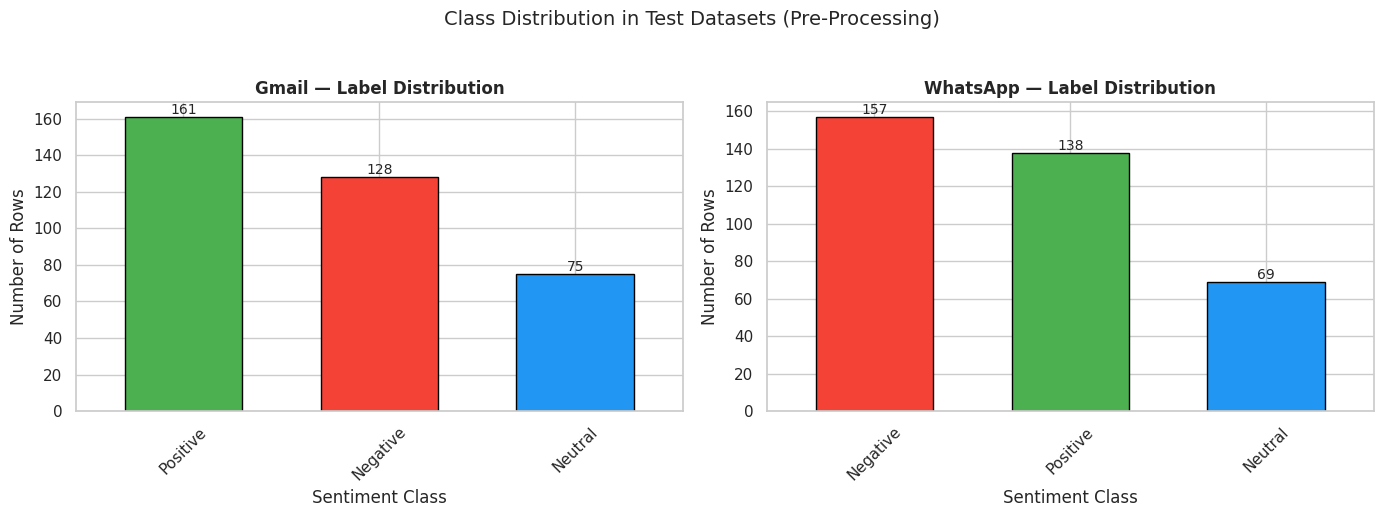

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Common colors for consistency
sentiment_colors = {
    'positive': '#4CAF50',
    'neutral': '#2196F3',
    'negative': '#F44336'
}

# Helper to plot mapped colors or fallback to a default
def get_colors(index):
    return [sentiment_colors.get(str(i).lower(), '#9E9E9E') for i in index]

# Dataset 1: Gmail
gmail_counts = df_gmail_raw['sentiment'].value_counts(dropna=False)
gmail_counts.plot(
    kind='bar', ax=axes[0], color=get_colors(gmail_counts.index), edgecolor='black', width=0.6
)
axes[0].set_title('Gmail — Label Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Rows')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )


# Dataset 2: WhatsApp
whatsapp_counts = df_whatsapp_raw['sentiment'].value_counts(dropna=False)
whatsapp_counts.plot(
    kind='bar', ax=axes[1], color=get_colors(whatsapp_counts.index), edgecolor='black', width=0.6
)
axes[1].set_title('WhatsApp — Label Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Number of Rows')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )


plt.suptitle('Class Distribution in Test Datasets (Pre-Processing)', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('viz_test_distribution_before_merge.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight**: The bar charts confirm what the numbers showed. Gmail is mostly Positive 
(161) the majority of student emails are neutral notifications or good news like 
acceptances and confirmations. WhatsApp flips this, with Negative being the most 
common (157) chats tend to carry more frustration, stress, and complaints. Both 
datasets have Neutral as the smallest class, which is expected since people rarely 
write something completely emotionless. This imbalance is something our models will 
need to handle carefully.

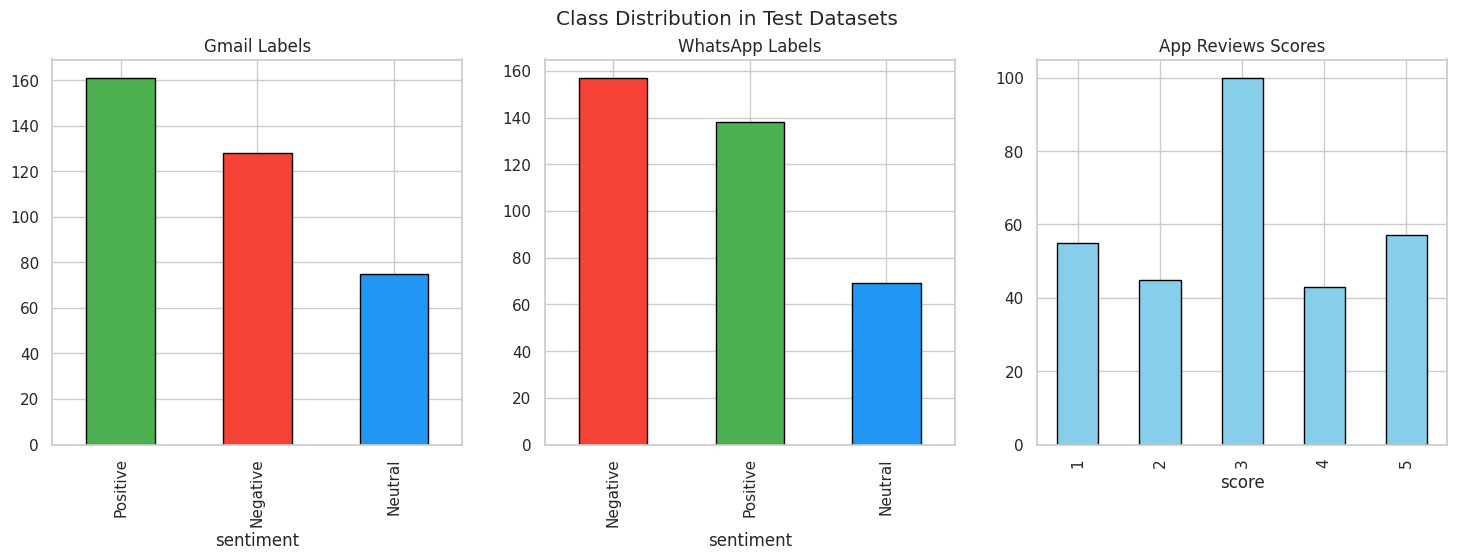

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiment_colors = {'positive': '#4CAF50', 'neutral': '#2196F3', 'negative': '#F44336'}
def get_colors(index):
    return [sentiment_colors.get(str(i).lower(), '#9E9E9E') for i in index]

df_gmail_raw['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=get_colors(df_gmail_raw['sentiment'].value_counts().index), edgecolor='black')
axes[0].set_title('Gmail Labels')

df_whatsapp_raw['sentiment'].value_counts().plot(kind='bar', ax=axes[1], color=get_colors(df_whatsapp_raw['sentiment'].value_counts().index), edgecolor='black')
axes[1].set_title('WhatsApp Labels')

if 'score' in df_app_reviews_raw.columns:
    df_app_reviews_raw['score'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='skyblue', edgecolor='black')
    axes[2].set_title('App Reviews Scores')

plt.suptitle('Class Distribution in Test Datasets')
plt.show()

**Insight**: This chart shows all three test datasets side by side before any 
cleaning. Gmail and WhatsApp already have sentiment labels so we can see the 
class split clearly. App Reviews shows star scores (1–5) instead of sentiment 
labels because at this point they had not been labelled yet. Score 3 is the 
most common. We later manually converted these reviews into Positive, Negative, and Neutral 
labels ourselves.

## 5. Data Cleaning And Preprocessing

In [95]:
# Maps any sentiment label to one of three standard classes: Positive, Negative, or Neutral and Returns None for labels we cannot confidently map.

def normalize_label(label):
    
    label = str(label).strip().lower()
 
    positive_labels = [
        'positive', 'joy', 'happiness', 'happy', 'love', 'excitement',
        'excited', 'contentment', 'content', 'gratitude', 'grateful',
        'serenity', 'serene', 'hopeful', 'hope', 'awe', 'pride',
        'acceptance', 'relief', 'mischievous', 'enthusiasm'
    ]
 
    negative_labels = [
        'negative', 'anger', 'angry', 'fear', 'sadness', 'sad',
        'disgust', 'disgusted', 'grief', 'despair', 'loneliness',
        'lonely', 'embarrassed', 'embarrassment', 'hate', 'bad',
        'nostalgia', 'confusion', 'confused', 'anxiety', 'anxious'
    ]
 
    neutral_labels = [
        'neutral', 'curiosity', 'curious', 'surprise', 'surprised'
    ]
 
    if label in positive_labels:
        return 'Positive'
    elif label in negative_labels:
        return 'Negative'
    elif label in neutral_labels:
        return 'Neutral'
    else:
        # Any label we cannot confidently classify is dropped
        return None
 

## 5.1 Training Data Preprocessing and Cleaning

### Dropping useless Columns for the trainiing datasets

In [96]:
df_sentiment_raw = df_sentiment[['Text', 'Sentiment']]
df_tweets_raw = df_tweets[['text', 'airline_sentiment']]
df_twitterdataset_raw = df_twitterdataset[['text', 'sentiment']]

### Renaming the training dataset columns to a consistent standard 

In [97]:

df_sentiment_raw = df_sentiment_raw.rename(columns={'Text': 'text', 'Sentiment': 'sentiment'})
df_tweets_raw = df_tweets_raw.rename(columns={'airline_sentiment': 'sentiment'})

### Viewing the available columns

In [98]:
print("        After Dropping Useless Columns")
print(f"df_sentiment columns: {df_sentiment_raw.columns.tolist()}")
print()
print(f"df_tweets columns: {df_tweets_raw.columns.tolist()}")
print()
print(f"df_twitterdataset columns: {df_twitterdataset_raw.columns.tolist()}")
print()

        After Dropping Useless Columns
df_sentiment columns: ['text', 'sentiment']

df_tweets columns: ['text', 'sentiment']

df_twitterdataset columns: ['text', 'sentiment']



### Dropping rows where text or sentiment is null

In [99]:
df_social_raw = df_sentiment_raw.dropna(subset=['text', 'sentiment'])
df_tweets_raw = df_tweets_raw.dropna(subset=['text', 'sentiment'])
df_twitterdataset_raw = df_twitterdataset_raw.dropna(subset=['text', 'sentiment'])


### Remove Duplicates with in each dataset

In [100]:

print("          Removing Duplicates")
for name, df in [("df_sentiment_raw", df_sentiment_raw), ("df_tweets_raw", df_tweets_raw), ("df_twitterdataset_raw", df_twitterdataset_raw)]:
    before = len(df)
    df.drop_duplicates(subset=['text'], inplace=True)
    print(f"{name}: {before} -> {len(df)} records")



print()
print("         Duplicates check Before Removal ")
print(f"df_sentiment duplicates: {df_sentiment_raw.duplicated(subset='text').sum()}")
print(f"df_tweets duplicates: {df_tweets_raw.duplicated(subset='text').sum()}")
print(f"df_twitterdataset duplicates: {df_twitterdataset_raw.duplicated(subset='text').sum()}")


print()
print("After removing duplicates within each dataset:")
print(f"df_sentiment → {df_sentiment_raw.shape[0]} rows")
print(f"df_tweets → {df_tweets_raw.shape[0]} rows")
print(f"df_twitterdataset → {df_twitterdataset_raw.shape[0]} rows")

          Removing Duplicates
df_sentiment_raw: 732 -> 707 records
df_tweets_raw: 14640 -> 14427 records
df_twitterdataset_raw: 73824 -> 69490 records

         Duplicates check Before Removal 
df_sentiment duplicates: 0
df_tweets duplicates: 0
df_twitterdataset duplicates: 0

After removing duplicates within each dataset:
df_sentiment → 707 rows
df_tweets → 14427 rows
df_twitterdataset → 69490 rows


**Insight**: We removed duplicate text entries from each dataset before merging. 
`sentimentdataset.csv` lost 25 rows, `Tweets.csv` lost 213, and `twitterdataset.csv` 
lost 4,334 — meaning a good number of tweets were identical copies. After removal 
the duplicate check correctly shows 0 remaining duplicates in all three datasets, 
confirming the cleaning worked.

### Applying the normalise label function to map the classes 
This helps to change those other sentiments to consistent labels of Positive, Negative and Neutral

In [101]:
df_sentiment_raw['sentiment'] = df_sentiment_raw['sentiment'].apply(normalize_label)
df_tweets_raw['sentiment'] = df_tweets_raw['sentiment'].apply(normalize_label)
df_twitterdataset_raw['sentiment'] = df_twitterdataset_raw['sentiment'].apply(normalize_label)


### Visualising the class distribution


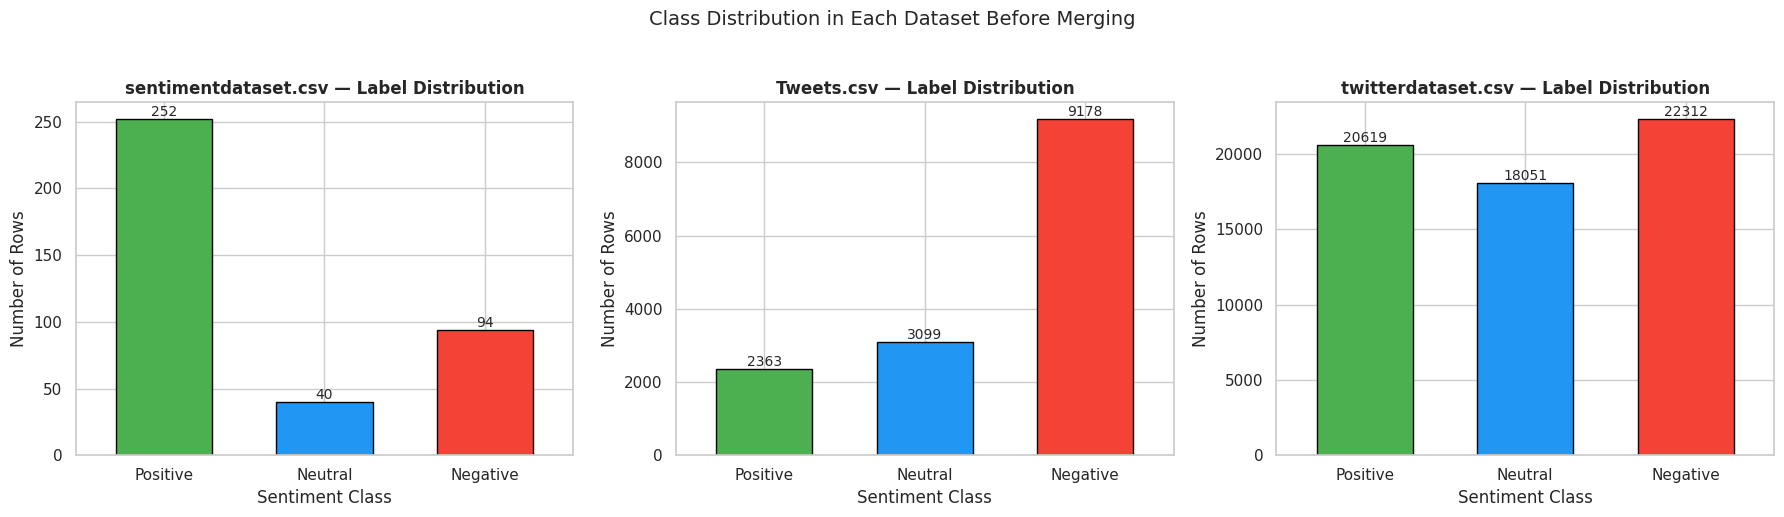

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sentiment_order = ['Positive', 'Neutral', 'Negative']
sentiment_colors = {'Positive': '#4CAF50', 'Neutral': '#2196F3', 'Negative': '#F44336'}
bar_colors = [sentiment_colors[s] for s in sentiment_order]

datasets = [
    (df_sentiment['Sentiment'].apply(normalize_label), 'sentimentdataset.csv'),
    (df_tweets['airline_sentiment'].apply(normalize_label), 'Tweets.csv'),
    (df_twitterdataset['sentiment'].apply(normalize_label), 'twitterdataset.csv'),
]

for ax, (series, title) in zip(axes, datasets):
    series.value_counts().reindex(sentiment_order, fill_value=0).plot(
        kind='bar', ax=ax, color=bar_colors, edgecolor='black', width=0.6
    )
    ax.set_title(f'{title} — Label Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentiment Class')
    ax.set_ylabel('Number of Rows')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2.0, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Class Distribution in Each Dataset Before Merging', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('viz1_distribution_before_merge.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight**: All three training datasets are imbalanced but in different ways. 
`sentimentdataset.csv` is heavily Positive (252) with very few Neutral examples (40). 
`Tweets.csv` is dominated by Negative (9,178) which makes sense since it comes from 
airline complaints on Twitter. `twitterdataset.csv` is the most balanced of the three 
but still has slightly more Negative (22,312) than the other classes. When we merge 
these together we will need to balance the classes so the model does not just learn 
to predict Negative all the time.

### Dropping rows where label could not be mapped and also viewing what was changed and what was not 

In [103]:
before_sentiment_r = len(df_sentiment_raw)
before_tweets = len(df_tweets_raw)
before_twitterdataset = len(df_twitterdataset_raw)

# Drop rows where normalize_label returned None
df_sentiment_raw = df_sentiment_raw.dropna(subset=['sentiment'])
df_tweets_raw = df_tweets_raw.dropna(subset=['sentiment'])
df_twitterdataset_raw = df_twitterdataset_raw.dropna(subset=['sentiment'])
 
print("           Label Normalisation")
print(f"df_sentiment: {before_sentiment_r} → {len(df_sentiment_raw)} rows (dropped {before_sentiment_r - len(df_sentiment_raw)} unmappable labels)")
print(f"df_tweets: {before_tweets} → {len(df_tweets_raw)} rows (dropped {before_tweets - len(df_tweets_raw)} unmappable labels)")
print(f"df_twitterdataset: {before_twitterdataset} → {len(df_twitterdataset_raw)} rows (dropped {before_twitterdataset - len(df_twitterdataset_raw)} unmappable labels)")


print()
print("df_sentiment label distribution after normalisation:")
print(df_sentiment_raw['sentiment'].value_counts())


print() 
print("df_tweets label distribution after normalisation:")
print(df_tweets_raw['sentiment'].value_counts())


print()
print("df_twitterdataset label distribution after normalisation:")
print(df_twitterdataset_raw['sentiment'].value_counts())
 
 

           Label Normalisation
df_sentiment: 707 → 378 rows (dropped 329 unmappable labels)
df_tweets: 14427 → 14427 rows (dropped 0 unmappable labels)
df_twitterdataset: 69490 → 57275 rows (dropped 12215 unmappable labels)

df_sentiment label distribution after normalisation:
sentiment
Positive    245
Negative     93
Neutral      40
Name: count, dtype: int64

df_tweets label distribution after normalisation:
sentiment
Negative    9080
Neutral     3057
Positive    2290
Name: count, dtype: int64

df_twitterdataset label distribution after normalisation:
sentiment
Negative    21166
Positive    19067
Neutral     17042
Name: count, dtype: int64


**Insight**: After mapping all labels to Positive, Negative, and Neutral, any row 
whose label could not be mapped was dropped. `sentimentdataset.csv` lost the most — 
329 rows had labels like "Irrelevant" that don't fit any of our three classes. 
`twitterdataset.csv` lost 12,215 rows for the same reason. `Tweets.csv` lost none 
since all its labels mapped cleanly. After this step we have 378 + 14,427 + 57,275 
= 72,080 rows of clean, consistently labelled training data ready to merge.

### Merging the Datasets into one 

In [104]:
# MERGE THE THREE DATASETS

df_sentiment_raw['source'] = 'social_media'
df_tweets_raw['source'] = 'airline_tweets'
df_twitterdataset_raw['source'] = 'twitterdataset'

combined_df = pd.concat([df_sentiment_raw, df_tweets_raw, df_twitterdataset_raw], ignore_index=True)

print("        After Merging:")
print(f"Combined dataset → {combined_df.shape[0]} rows")
print()
print("Source breakdown:")
print(combined_df['source'].value_counts())

        After Merging:
Combined dataset → 72080 rows

Source breakdown:
source
twitterdataset    57275
airline_tweets    14427
social_media        378
Name: count, dtype: int64


/tmp/ipykernel_189/757105748.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_twitterdataset_raw['source'] = 'twitterdataset'


**Insight**: The three datasets have been successfully merged into one combined 
dataset of 72,080 rows. As expected, `twitterdataset.csv` contributes the most 
(57,275 rows), followed by airline tweets (14,427), and the smallest contribution 
from `sentimentdataset.csv` (378 rows. The data merged correctly and nothing was lost.

### Removing cross dataset duplicates

In [105]:
before_merge_dedup = len(combined_df)
combined_df = combined_df.drop_duplicates(subset='text').reset_index(drop=True)
print(f"\nCross-dataset duplicates removed: {before_merge_dedup - len(combined_df)}")
print(f"Combined dataset after removing duplicates → {combined_df.shape[0]} rows")

# Save a copy BEFORE balancing for later comparison charts
combined_before_balance = combined_df.copy()



Cross-dataset duplicates removed: 0
Combined dataset after removing duplicates → 72080 rows


**Insight**: After checking for duplicates across all three merged datasets, zero 
cross-dataset duplicates were found. This means none of the tweets or posts appeared 
in more than one source, so all 72,080 rows are unique and we keep everything.

### Balancing the Dataset by Reducing Negative Samples

In [106]:

# Reduce Negative class by 5000 samples in the combined dataset
negative_mask = combined_df['sentiment'] == 'Negative'
negative_count_before = int(negative_mask.sum())
remove_n = min(5000, negative_count_before)

if remove_n > 0:
    drop_idx = combined_df[negative_mask].sample(n=remove_n, random_state=42).index
    combined_df = combined_df.drop(index=drop_idx).reset_index(drop=True)

# Save a copy AFTER balancing
combined_balanced = combined_df.copy()

negative_count_after = int((combined_df['sentiment'] == 'Negative').sum())
print(f"Negative samples removed: {remove_n}")
print(f"Negative count: {negative_count_before} → {negative_count_after}")
print(f"Combined dataset after downsampling → {combined_df.shape[0]} rows")

Negative samples removed: 5000
Negative count: 30339 → 25339
Combined dataset after downsampling → 67080 rows


**Insight**: Before balancing, the Negative class had 30,339 rows significantly 
more than Positive and Neutral. To stop the model from being biased toward predicting 
Negative too often, we randomly removed 5,000 Negative samples bringing it down to 
25,339. The final combined dataset now has 67,080 rows which is what gets split into 
our training (46,956) and validation (20,124) sets.

### Class Imbalance check

In [107]:
print("Checking Class Imbalance ")
class_counts = combined_df['sentiment'].value_counts()
print(class_counts)
 
majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = majority / minority
print(f"\nImbalance ratio (majority / minority): {imbalance_ratio:.2f}x")
 
if imbalance_ratio > 2:
    print("  Imbalance detected — balancing required")
else:
    print(" Classes are reasonably balanced")

Checking Class Imbalance 
sentiment
Negative    25339
Positive    21602
Neutral     20139
Name: count, dtype: int64

Imbalance ratio (majority / minority): 1.26x
 Classes are reasonably balanced


**Insight**: After downsampling, the imbalance ratio between the largest and smallest 
class is only 1.26x meaning the biggest class (Negative, 25,339) is just 26% 
larger than the smallest (Neutral, 20,139). That is well within acceptable range and 
the check confirms the classes are reasonably balanced. Our model will now get a fair 
exposure to all three sentiments during training without being pulled too strongly in 
any one direction.

### Class Distribution after merging

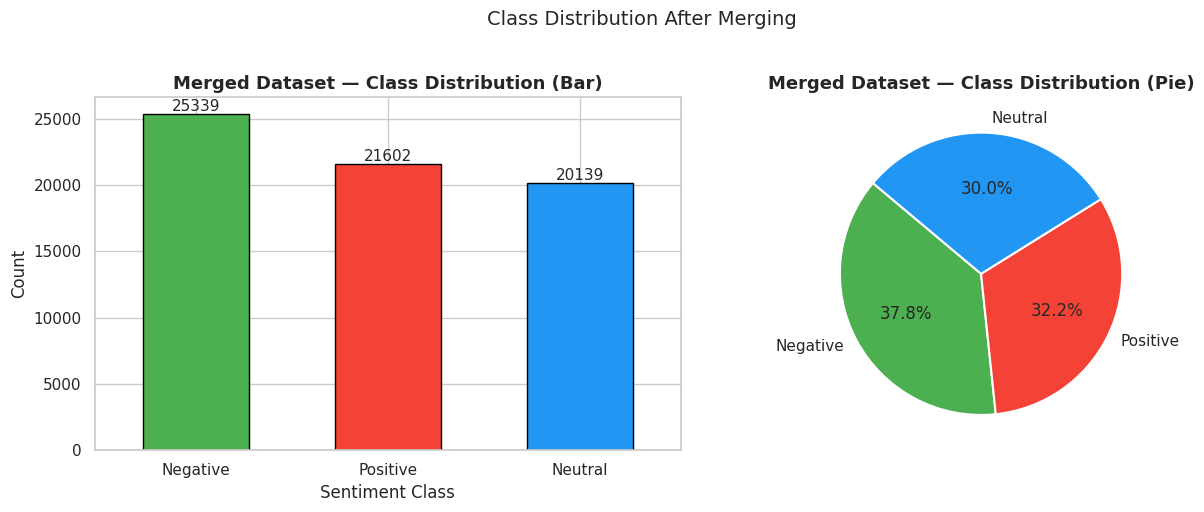

Saved: viz2_distribution_after_merge.png


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Bar chart
colors = ['#4CAF50', '#F44336', '#2196F3']
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.55)
axes[0].set_title('Merged Dataset — Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)
 
# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Merged Dataset — Class Distribution (Pie)', fontsize=13, fontweight='bold')
 
plt.suptitle('Class Distribution After Merging', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz2_distribution_after_merge.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz2_distribution_after_merge.png")
 
 

**Insight**: The bar and pie charts together show a well-balanced final training 
dataset. Negative holds the largest share at 37.8%, followed by Positive at 32.2% 
and Neutral at 30.0%. The difference between the largest and smallest class is just 
over 5,000 rows — small enough that the model will learn all three classes fairly 
without strong bias toward any one of them.

###   Before vs After balancing visualisation (side by side)

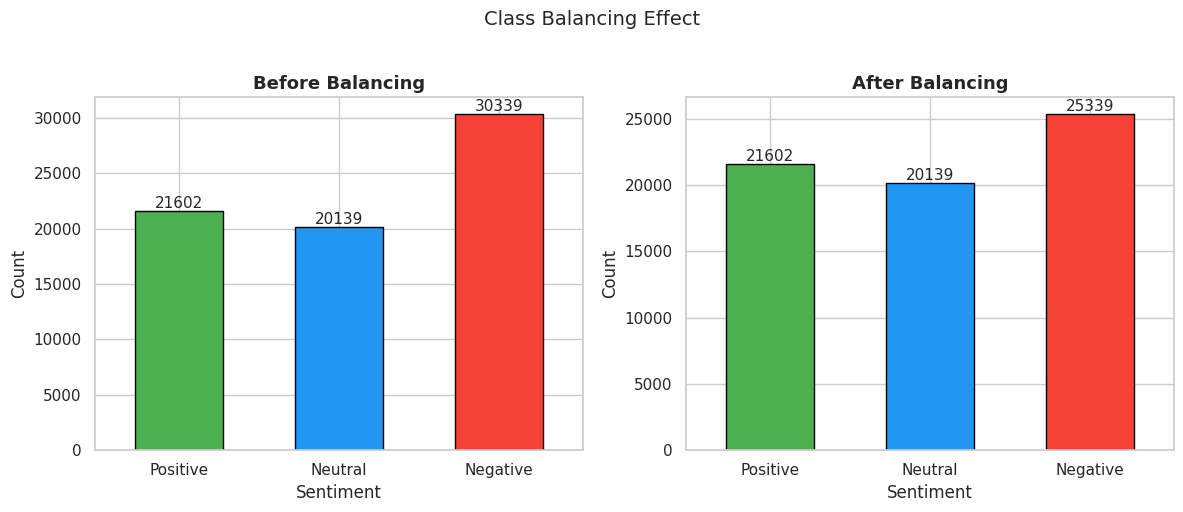

Saved: viz3_balancing_effect.png


In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sentiment_order = ['Positive', 'Neutral', 'Negative']
sentiment_colors = {
    'Positive': '#4CAF50',
    'Neutral': '#2196F3',
    'Negative': '#F44336'
}
bar_colors = [sentiment_colors[s] for s in sentiment_order]

before_counts = combined_before_balance['sentiment'].value_counts().reindex(sentiment_order, fill_value=0)
after_counts = combined_balanced['sentiment'].value_counts().reindex(sentiment_order, fill_value=0)

before_counts.plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='black', width=0.55)
axes[0].set_title('Before Balancing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

after_counts.plot(kind='bar', ax=axes[1], color=bar_colors, edgecolor='black', width=0.55)
axes[1].set_title('After Balancing', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

plt.suptitle('Class Balancing Effect', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz3_balancing_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz3_balancing_effect.png')

**Insight**: The side by side comparison clearly shows the effect of downsampling. 
Before balancing, Negative (30,339) was almost 50% larger than Neutral (20,139), 
which would have pushed the model to over-predict Negaive. After removing 5,000 
random Negative samples, all three classes now sit within a much closer range of 
each other making it a fair training environment for the model.

###  Text length distribution by sentiment class

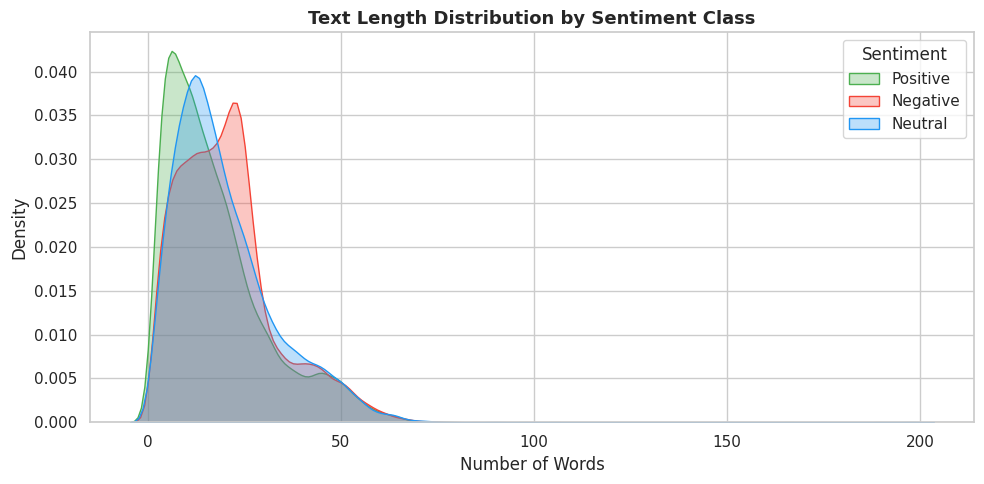

Saved: viz4_text_length_distribution.png


In [110]:
# This helps us understand whether positive/negative/neutral posts
# tend to be longer or shorter — useful context for the report.
combined_balanced['text_length'] = combined_balanced['text'].str.split().str.len()
 
plt.figure(figsize=(10, 5))
for label, color in zip(['Positive', 'Negative', 'Neutral'], colors):
    subset = combined_balanced[combined_balanced['sentiment'] == label]['text_length']
    sns.kdeplot(subset, label=label, color=color, fill=True, alpha=0.3)
 
plt.title('Text Length Distribution by Sentiment Class', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Density')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('viz4_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz4_text_length_distribution.png")

**Insight**: All three sentiment classes follow a very similar text length pattern — 
most posts are short, peaking between 10 and 30 words, with a long tail of a few 
longer posts stretching past 100 words. Positive messages tend to be the shortest 
on average, while Negative messages have a slightly longer tail, suggesting that 
people tend to write more when expressing frustration or complaints. Neutral messages 
sit in between. Overall the distributions are close enough that text length alone is 
not a strong signal for sentiment.

### Source contribution to final dataset visualisation

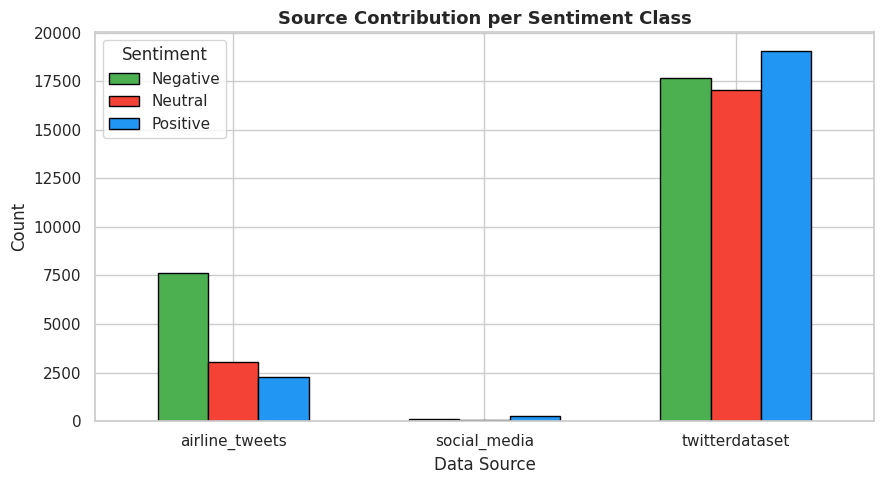

Saved: viz5_source_contribution.png


In [111]:
# Shows how much each original dataset contributed after balancing.
 
source_sentiment = combined_balanced.groupby(
    ['source', 'sentiment']
).size().unstack(fill_value=0)
 
source_sentiment.plot(
    kind='bar', color=colors, edgecolor='black', width=0.6, figsize=(9, 5)
)
plt.title('Source Contribution per Sentiment Class', fontsize=13, fontweight='bold')
plt.xlabel('Data Source')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('viz5_source_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz5_source_contribution.png")

**Insight**: `twitterdataset` is by far the biggest contributor, providing roughly 
equal amounts of all three classes — making it the backbone of our training data. 
`airline_tweets` contributes heavily but almost entirely Negative examples, which 
is expected since it comes from customer complaints. `social_media` contributes very 
little overall due to its small size (378 rows after cleaning).

### Word Cloud — Most Frequent Words Per Sentiment Class

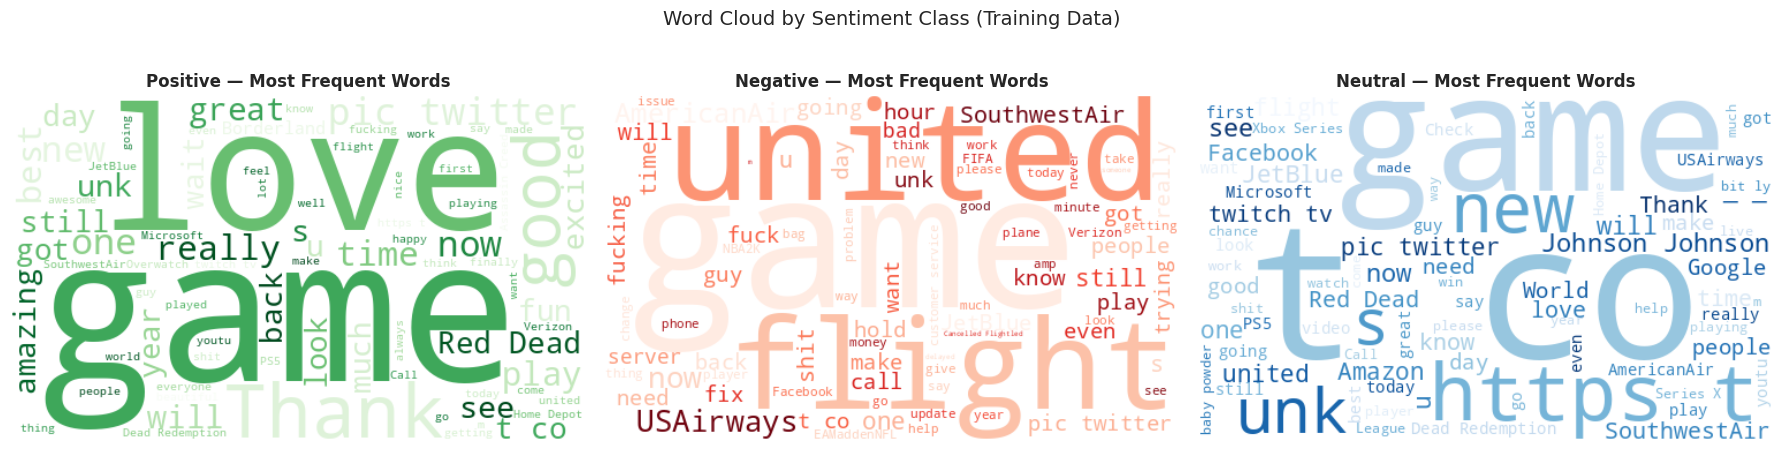

Saved: viz6_wordclouds.png


In [112]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
wc_sentiments = ['Positive', 'Negative', 'Neutral']
wc_cmaps = ['Greens', 'Reds', 'Blues']

for ax, sentiment, cmap in zip(axes, wc_sentiments, wc_cmaps):
    text = ' '.join(combined_balanced[combined_balanced['sentiment'] == sentiment]['text'].dropna().astype(str))
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} — Most Frequent Words', fontsize=12, fontweight='bold')

plt.suptitle('Word Cloud by Sentiment Class (Training Data)', fontsize=14)
plt.tight_layout()
plt.savefig('viz6_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz6_wordclouds.png")

**Insight**: The word clouds reveal what kind of language dominates each class. 
Positive posts are full of words like "good", "love", "great", "thank" and "fun" — 
the kind of language you see when people are happy or excited. Negative posts are 
dominated by airline names like "United", "SouthwestAir", "JetBlue" and frustrated 
words like "bad", "hour", "call" — confirming that the airline complaints dataset 
is heavily driving the Negative class. Neutral posts are noisier, with "https", 
"twitter" and airline names appearing frequently, suggesting many neutral tweets 
are just informational or factual posts with no strong emotion. This is useful 
context — our model has learned "United" and "JetBlue" as Negative signals, but 
those words won't appear in student Gmail or WhatsApp messages, which is a key 
part of why domain shift is a real challenge here.

### Split and Save Training and Validation sets

In [113]:
final_df = combined_balanced[['text', 'sentiment']].copy()

final_df = final_df.dropna(subset=['sentiment'])
final_df = final_df[final_df['sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

train_df, val_df = train_test_split(
    final_df,
    test_size=0.30,
    random_state=42,
    stratify=final_df['sentiment']
)

train_path = 'data/processed/processed_training_dataset.csv'
val_path = 'data/processed/processed_validation_datset.csv'

#train_df.to_csv(train_path, index=False)
#val_df.to_csv(val_path, index=False)

print("           Final Summary")
print(f"Training dataset saved: {len(train_df)} rows")
print(f"Validation dataset saved: {len(val_df)} rows")
print()
print("Training class distribution:")
print(train_df['sentiment'].value_counts())
print()
print("Validation class distribution:")
print(val_df['sentiment'].value_counts())

           Final Summary
Training dataset saved: 46956 rows
Validation dataset saved: 20124 rows

Training class distribution:
sentiment
Negative    17737
Positive    15122
Neutral     14097
Name: count, dtype: int64

Validation class distribution:
sentiment
Negative    7602
Positive    6480
Neutral     6042
Name: count, dtype: int64


## 5.2 Test Data Preprocessing and Cleaning

### Dropping Duplicates

In [114]:
df_gmail = df_gmail_raw.drop_duplicates(subset=['text']).reset_index(drop=True)
df_whatsapp = df_whatsapp_raw.drop_duplicates(subset=['text']).reset_index(drop=True)

# App reviews: load from the already-labelled file (has 'text' and 'sentiment' columns)
# The raw file only has 'content' and no sentiment — labelling was done manually
df_app_reviews = pd.read_csv('/kaggle/input/datasets/tagooledavid256/last-rider/labelled_app_reviews_test.csv').drop_duplicates(subset=['text']).reset_index(drop=True)

print(f"Gmail cleaned: {len(df_gmail)}")
print(f"WhatsApp cleaned: {len(df_whatsapp)}")
print(f"App Reviews cleaned: {len(df_app_reviews)}")
print(f"App Reviews columns: {df_app_reviews.columns.tolist()}")

Gmail cleaned: 348
WhatsApp cleaned: 318
App Reviews cleaned: 292
App Reviews columns: ['text', 'sentiment']


**Insight**: After removing duplicate messages, Gmail has 348 rows, WhatsApp 318, 
and App Reviews 292 — giving us 958 test examples across three domains. Gmail and 
WhatsApp lost a few rows from deduplication (from 364 each), while App Reviews loads 
directly from the manually labelled file with exactly the two columns we need: `text` 
and `sentiment`.

 We define a robust cleaning function using regular expressions to strip signatures, HTML, and specific noise markers identified during EDA.

In [115]:
def clean_the_text(text):
    # Remove HTML tags (<div>, <br>, etc.)
    text = re.sub(r'<.*?>', '', text)
    
    # Remove Forwarded message markers and signatures
    text = re.sub(r'--- Forwarded message ---', '', text)
    text = re.sub(r'Please consider the environment', '', text, flags=re.I)
    text = re.sub(r'Sent from my (iPhone|mobile|Android|iPhone)', '', text, flags=re.I)
    text = re.sub(r'Best regards, .*', '', text, flags=re.I)
    
    # Remove service markers (MTN:, GitHub:, etc.)
    text = re.sub(r'(MTN|GitHub|Vercel|Udemy|Vultr|CodeMagic|LinkedIn|Amazon|Railway|Netlify|Heroku):', '', text, flags=re.I)

    # Remove specific noise characters (!!!, ???, @user)
    text = re.sub(r'!!!|\?\?\?|@user', '', text)
    
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


df_gmail['clean_text'] = df_gmail['text'].apply(clean_the_text)
df_whatsapp['clean_text'] = df_whatsapp['text'].apply(clean_the_text)
df_app_reviews['clean_text'] = df_app_reviews['text'].apply(clean_the_text)

# Note: df_app_reviews['sentiment'] will be provided via manual labeling in Excel

### First five columns of the Data

In [116]:
print("       Gmail ")
display(df_gmail[['text', 'clean_text']].head())
print()
print()


print("       WhatsApp ")
display(df_whatsapp[['text', 'clean_text']].head())
print()


print("       App Reviews ")
display(df_app_reviews[['clean_text']].head())
print()
print()


       Gmail 


,text,clean_text
0,@user GitHub: Security alert - A new SSH key w...,Security alert - A new SSH key was added.
1,!!! Vultr: Monthly invoice is ready for review...,Monthly invoice is ready for review.
2,<br> Coursera: Financial Aid for 'Machine Lear...,Coursera: Financial Aid for 'Machine Learning'...
3,@user Udemy: Registration Successful! Welcome ...,Registration Successful! Welcome to 'Deep Lear...
4,??? You've won a $1000 prize! Claim your rewar...,You've won a $1000 prize! Claim your reward now!




       WhatsApp 


,text,clean_text
0,@user The payment for the course went through!...,The payment for the course went through!
1,"<br> Bro, the card declined again at the mall....","Bro, the card declined again at the mall. Emba..."
2,??? MTN: Subscription of 10GB Data successful....,Subscription of 10GB Data successful. Balance:...
3,<br> The wifi in the hostel is down again. I h...,The wifi in the hostel is down again. I hate t...
4,<div> I'm breaking up with this internship. No...,I'm breaking up with this internship. No pay.



       App Reviews 


,clean_text
0,Awesome!! Easy to use......just perfect!
1,"I like this app, because it fits well in my da..."
2,"I am a vanilla habitician, but that game faile..."
3,The best app for people with or without ADHD
4,Great tool for coordinating between family mem...


### Dropping the columns that are not needed & Saving the datasets

We finalise each test domain by selecting only the `text`, `sentiment`, and `source` columns.
Note: App Reviews were manually labelled in Excel and saved separately as `labelled_app_reviews_test.csv`,
so we load that file directly rather than deriving it from the raw file which has no sentiment column.

In [117]:

df_gmail['source'] = 'Gmail'
df_whatsapp['source'] = 'WhatsApp'

# Select final columns for Gmail and WhatsApp
gmail_final = df_gmail[['clean_text', 'sentiment', 'source']].rename(columns={'clean_text': 'text'})
whatsapp_final = df_whatsapp[['clean_text', 'sentiment', 'source']].rename(columns={'clean_text': 'text'})

# App Reviews: sentiment was manually labelled and already saved separately
# We load it directly and just add the source column
app_reviews_final = pd.read_csv('/kaggle/input/datasets/tagooledavid256/last-rider/labelled_app_reviews_test.csv')
app_reviews_final['source'] = 'App Reviews'

# Save
# gmail_final.to_csv('/kaggle/working/gmail_test_data.csv', index=False)
# whatsapp_final.to_csv('/kaggle/working/whatsapp_test_data.csv', index=False)
# app_reviews_final.to_csv('/kaggle/working/labelled_app_reviews_test.csv', index=False)

print(f"Gmail final: {len(gmail_final)} rows, columns: {gmail_final.columns.tolist()}")
print(f"WhatsApp final: {len(whatsapp_final)} rows, columns: {whatsapp_final.columns.tolist()}")
print(f"App Reviews final: {len(app_reviews_final)} rows, columns: {app_reviews_final.columns.tolist()}")

Gmail final: 348 rows, columns: ['text', 'sentiment', 'source']
WhatsApp final: 318 rows, columns: ['text', 'sentiment', 'source']
App Reviews final: 292 rows, columns: ['text', 'sentiment', 'source']


### Class Distribution of Final Labelled Test Datasets

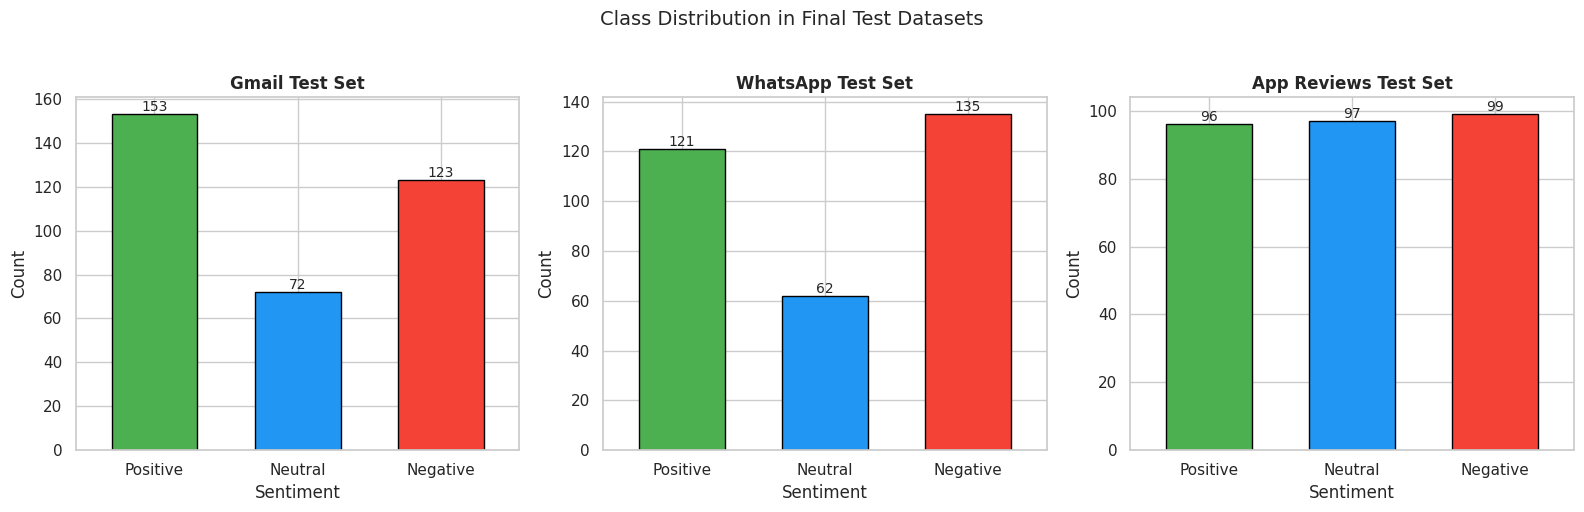

Saved: viz7_test_set_distribution.png


In [118]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sentiment_order = ['Positive', 'Neutral', 'Negative']
bar_colors = ['#4CAF50', '#2196F3', '#F44336']

for ax, df, title in zip(axes,
    [gmail_final, whatsapp_final, app_reviews_final],
    ['Gmail Test Set', 'WhatsApp Test Set', 'App Reviews Test Set']):
    counts = df['sentiment'].value_counts().reindex(sentiment_order, fill_value=0)
    counts.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='black', width=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentiment'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Class Distribution in Final Test Datasets', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz7_test_set_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz7_test_set_distribution.png")

**Insight**: The three test sets each tell a different story. Gmail is Positive-heavy 
(153) which reflects the nature of student emails — most are confirmations, approvals 
or updates rather than complaints. WhatsApp flips this with Negative leading (135), 
showing that chat messages carry more stress and frustration. App Reviews is the most 
balanced of the three (96, 97, 99) — almost perfectly even across all three classes, 
which makes it the fairest domain to evaluate on. Together these 958 test examples 
give us a good spread of real-world language styles to challenge our models with.

## 6. Feature Engineering

Before training, we prepare two types of features from every message. 
First, we extract 12 handcrafted metadata features like exclamation counts, 
word count, and whether the message mentions a platform or academic keyword. These 
give the models signals that raw text alone might miss. Second, we clean the text 
and convert it into two formats lik TF-IDF vectors for the classical models and integer 
sequences for the deep learning models. Sentiment labels are also mapped to numbers 
(Negative=0, Neutral=1, Positive=2) so the models can process them. All of this 
happens across all four datasets — training, Gmail, WhatsApp, and App Reviews so 
every dataset is prepared in exactly the same way before any model sees it.

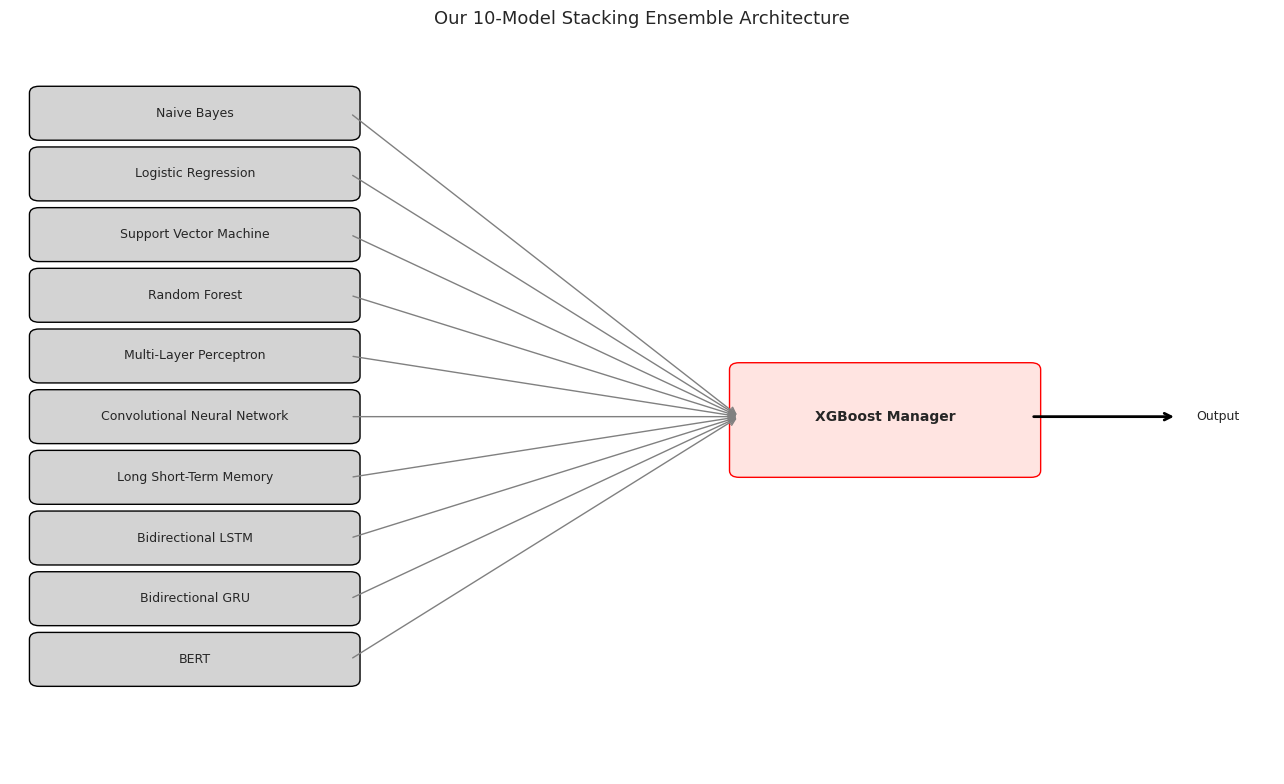

In [119]:
def extract_meta_features(df):
    df = df.copy()
    df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
    df['question_count'] = df['text'].apply(lambda x: str(x).count('?'))
    df['is_all_caps'] = df['text'].apply(lambda x: 1 if str(x).isupper() and len(str(x)) > 5 else 0)
    df['char_cnt'] = df['text'].apply(lambda x: len(str(x)))
    df['word_cnt'] = df['text'].apply(lambda x: len(str(x).split()))
    
    platforms = r'github|slack|coursera|udemy|paystack|railway|netlify|heroku|mtn|airtel|gmail|whatsapp'
    alerts = r'invoice|billing|service termination|payment receipt|account alert|reminder notice|transaction'
    academic = r'assignment|deadline|exam|results|semester|lecture|submission|grade|marks|course'
    
    df['has_platform_mention'] = df['text'].apply(lambda x: 1 if re.search(platforms, str(x).lower()) else 0)
    df['has_service_alert'] = df['text'].apply(lambda x: 1 if re.search(alerts, str(x).lower()) else 0)
    df['exclamation_intensity'] = df['text'].apply(lambda x: min(str(x).count('!'), 5))
    df['technical_success'] = df['text'].apply(lambda x: 1 if re.search(r'successful|approved|passed|accepted|delivered|congratulations|internship|scholarship|live|verified|welcome|registered|great|amazing|won|celebrate', str(x).lower()) else 0)
    df['technical_failure'] = df['text'].apply(lambda x: 1 if re.search(r'failed|rejected|declined|suspended|expired|terminated|error|down|awful|hate|tired|annoying|struggling|frustrated|devastated|embarrassing|breaking', str(x).lower()) else 0)
    df['student_context_score'] = df['text'].apply(lambda x: len(re.findall(academic, str(x).lower())))
    df['positive_signal'] = df['text'].apply(lambda x: len(re.findall(r'congrats|congratulations|proud|excited|happy|amazing|passed|accepted|scholarship|won|celebrate|excellent|well done', str(x).lower())))
    return df

def surgical_cleaner(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = text.translate(str.maketrans('', '', ',.;:()[]{}<>/@#'))
    text = re.sub(r'\s+', ' ', text).strip()
    return text if text else "notification"


train_df = extract_meta_features(train_df) 
df_gmail = extract_meta_features(df_gmail)
df_whatsapp = extract_meta_features(df_whatsapp)
df_app_reviews = extract_meta_features(df_app_reviews)

train_df['clean'] = train_df['text'].apply(surgical_cleaner)
df_gmail['clean'] = df_gmail['text'].apply(surgical_cleaner)
df_whatsapp['clean'] = df_whatsapp['text'].apply(surgical_cleaner)
df_app_reviews['clean'] = df_app_reviews['text'].apply(surgical_cleaner)

metadata_columns = ['exclamation_count', 'question_count', 'is_all_caps', 'char_cnt', 'word_cnt', 'has_platform_mention', 'has_service_alert', 'exclamation_intensity', 'technical_success', 'technical_failure', 'student_context_score', 'positive_signal']

# 2. Map Categorical Sentiments to Numeric Labels
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
train_df['label'] = train_df['sentiment'].map(label_map)
df_gmail['label'] = df_gmail['sentiment'].map(label_map)
df_whatsapp['label'] = df_whatsapp['sentiment'].map(label_map)
df_app_reviews['label'] = df_app_reviews['sentiment'].map(label_map)


y_train = train_df['label'].values
y_gmail_true = df_gmail['label'].values
y_whatsapp_true = df_whatsapp['label'].values
y_app_true = df_app_reviews['label'].values







fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 13); ax.set_ylim(0, 11); ax.axis('off')

model_names = ['Naive Bayes', 'Logistic Regression', 'Support Vector Machine', 
               'Random Forest', 'Multi-Layer Perceptron', 'Convolutional Neural Network', 
               'Long Short-Term Memory', 'Bidirectional LSTM', 'Bidirectional GRU', 'BERT']

for i, m in enumerate(model_names):
    y = 9.5 - i * 0.9
    ax.add_patch(FancyBboxPatch((0.3, y), 3.2, 0.6, boxstyle="round,pad=0.1", ec="black", fc="lightgray"))
    ax.text(1.9, y + 0.3, m, ha='center', va='center', fontsize=9)
    ax.annotate('', xy=(7.5, 5.3), xytext=(3.5, y + 0.3),
                arrowprops=dict(arrowstyle='->', lw=1, color='gray'))

ax.add_patch(FancyBboxPatch((7.5, 4.5), 3, 1.5, boxstyle="round,pad=0.1", ec="red", fc="mistyrose"))
ax.text(9.0, 5.3, 'XGBoost Manager', ha='center', va='center', fontsize=10, fontweight='bold')

ax.annotate('', xy=(12, 5.3), xytext=(10.5, 5.3),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(12.2, 5.3, 'Output', ha='left', va='center', fontsize=9)

plt.title('Our 10-Model Stacking Ensemble Architecture', fontsize=13)
plt.tight_layout()
plt.show()






scaler = StandardScaler() 
X_train_meta = scaler.fit_transform(train_df[metadata_columns]) 
X_gmail_meta = scaler.transform(df_gmail[metadata_columns])
X_whatsapp_meta = scaler.transform(df_whatsapp[metadata_columns])
X_app_meta = scaler.transform(df_app_reviews[metadata_columns])





VOCAB_SIZE, MAX_LEN = 20000, 150
deeplearning_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
deeplearning_tokenizer.fit_on_texts(pd.concat([train_df['clean'], df_gmail['clean'], df_whatsapp['clean'], df_app_reviews['clean']]))

## 6.5 Domain Adaptation Strategies

To reduce the impact of domain shift — where models trained on Twitter are tested 
on Gmail, WhatsApp, and App Reviews — we applied four deliberate strategies:

**1. Stacking Ensemble**  
Rather than relying on one model, 10 models each make a prediction and XGBoost 
learns which to trust. Different models generalise differently, so the ensemble 
is naturally more robust across unseen domains.

**2. Student-Context Feature Engineering**  
We manually designed 12 features around the language students actually use — 
academic keywords like "exam" and "deadline", platform names like "GitHub" and 
"MTN", and success/failure signals like "scholarship" and "rejected". These give 
the models domain-aware signals that raw Twitter text alone would never provide.

**3. GloVe Pre-trained Embeddings**  
Instead of learning word meanings from scratch using only Twitter data, our deep 
learning models (CNN, LSTM, Bi-LSTM, Bi-GRU) start with GloVe vectors trained on 
billions of general internet sentences. This gives them a broader understanding of 
language that transfers better to new domains.

**4. Pseudo-Labelling**  
After the first round of predictions on the test domains, any example the model 
was highly confident about (above 85% probability) was added back into training 
and the final XGBoost meta-learner was retrained. This allows the model to 
partially adapt using the target domain's own data.

**GloVe (Global Vectors for Word 
Representation)** is a pre-trained set of word vectors from Stanford trained on 
billions of words from the internet.

Instead of letting the deep learning models learn word meanings from 
scratch, we give them a head start using **GloVe (Global Vectors for Word 
Representation)** Each word is represented as a list of 100 
numbers that capture its meaning and relationship to other words — for example, 
"happy" and "joyful" will have similar vectors while "happy" and "invoice" will 
be very different. We build an embedding matrix of shape (20,000 × 100) where 
each row corresponds to a word in our vocabulary and contains its 100-dimensional 
GloVe vector. This matrix is then loaded into the CNN, LSTM, Bi-LSTM and Bi-GRU 
models as their starting point, so they begin training already knowing what words 
mean rather than learning everything from zero.

In [120]:
glove_path = 'glove.6B.100d.txt'
if not os.path.exists(glove_path):
    urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z: z.extract(glove_path)

embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f: 
        v = line.split()
        embeddings_index[v[0]] = np.asarray(v[1:], dtype='float32')

embedding_matrix = np.zeros((VOCAB_SIZE, 100))
for word, i in deeplearning_tokenizer.word_index.items():
    if i < VOCAB_SIZE: 
        vec = embeddings_index.get(word)
        if vec is not None: embedding_matrix[i] = vec


## 7. Ensemble Model Training & Evaluation

This section sets up **DistilBERT** — our most powerful model and the 
only one in the ensemble that truly understands language context rather than just 
word frequencies. DistilBERT is a lighter, faster version of BERT (Bidirectional 
Encoder Representations from Transformers) that was pre-trained by Google on 
hundreds of millions of sentences. Instead of loading it from scratch, we load a 
pre-trained version and fine-tune it on our sentiment data — meaning it already 
knows English grammar and word meaning, and we are just teaching it the difference 
between Positive, Negative and Neutral in our specific context. It is trained for 
5 epochs with a small learning rate (3e-5) to avoid overwriting what it already 
knows. A fresh copy is trained in every fold so its predictions are always OOF 
just like the other 9 models.

In [121]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

class SentiDS(torch.utils.data.Dataset):
    def __init__(self, enc, lbl): self.enc = enc; self.lbl = lbl
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.lbl[idx]); return item
    def __len__(self): return len(self.lbl)

def train_distilbert(texts, labels):
    tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
    train_enc = tokenizer(list(texts), truncation=True, padding=True, max_length=128)
    train_lbl = list(labels)

    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=3,
        ignore_mismatched_sizes=True
    ).to(DEVICE)

    training_args = TrainingArguments(
        output_dir='./bert_out',
        num_train_epochs=5,
        per_device_train_batch_size=32,
        learning_rate=3e-5,
        warmup_steps=200,
        weight_decay=0.01,
        logging_steps=50,
        save_strategy='no',
        report_to='none',
        fp16=torch.cuda.is_available(),
        disable_tqdm=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,   
        train_dataset=SentiDS(train_enc, train_lbl)
    )
    trainer.train()
    return model, tokenizer

### Cross-Validation & Model Training Strategy

Rather than training each model once and hoping for the best, we use **5-Fold 
Stratified Cross-Validation**. This means we split the training data into 5 equal 
parts called folds. In each round, 4 parts are used for training and 1 part is used 
for validation. This repeats 5 times so that every single training example gets 
evaluated exactly once by a model that never saw it during training.

---

### How the Fold Loop Works

For each of the 5 folds, the following happens in order:

1. **TF-IDF vectors are built** from the training portion of that fold. TF-IDF 
   converts raw text into numbers by measuring how important each word is — common 
   words like "the" get low scores, while meaningful words like "failed" or 
   "congratulations" get high scores. We build two versions: one with 15,000 features 
   for most models, and a smaller one with 8,000 features specifically for Random Forest.

2. **Sequences are built** for the deep learning models (CNN, LSTM, Bi-LSTM, Bi-GRU, 
   DistilBERT). Instead of TF-IDF, these models need text converted into integer 
   sequences where each number represents a word in our vocabulary.

3. **All 10 models are trained** one by one on that fold's training split.

4. **Each model predicts on the validation split** it never saw. These predictions 
   are stored in a matrix called `train_predictions` — a table of shape 
   (67,080 rows × 30 columns), where every 3 columns hold the Negative, Neutral, 
   and Positive probabilities from one model.

5. **Each model also predicts on all 3 test sets** (Gmail, WhatsApp, App Reviews). 
   These predictions are averaged across all 5 folds so the final test predictions 
   are more stable and less dependent on any single fold.

6. **At the end of each fold**, we average the 10 models' probability columns into 
   a single (n × 3) array and take the highest probability as the predicted class. 
   This gives us the **OOF (Out-Of-Fold) accuracy** for that fold — a reliable 
   measure of how well the ensemble is doing without touching the test data.

---

### The Features Generated

Beyond the raw text, we also engineer **12 metadata features** for every message 
that give the models extra signals the text alone might miss:

| Feature | What It Captures |
|---|---|
| `exclamation_count` | How many `!` are in the message |
| `question_count` | How many `?` are in the message |
| `is_all_caps` | Whether the message is written in ALL CAPS |
| `char_cnt` | Total number of characters |
| `word_cnt` | Total number of words |
| `has_platform_mention` | Whether it mentions platforms like GitHub, MTN, Gmail, etc. |
| `has_service_alert` | Whether it contains words like "invoice", "payment", "terminated" |
| `exclamation_intensity` | Capped count of `!` — measures emotional intensity |
| `technical_success` | Words like "approved", "passed", "congratulations", "scholarship" |
| `technical_failure` | Words like "failed", "rejected", "suspended", "error" |
| `student_context_score` | How many academic words appear — "exam", "deadline", "grade" |
| `positive_signal` | Count of clearly positive phrases like "well done", "excited", "won" |

These 12 features are concatenated with the 30 model probability columns to form 
a final **42-column meta-dataset** that is passed to the XGBoost meta-learner.

---

### Why OOF (Out Of Fold) Accuracy Matters

**OOF (Out-Of-Fold)** means that for every training example, its prediction was 
made by a model that was trained without it. No example ever scores itself.

A regular train/test accuracy can be misleading — a model can score high simply 
by memorising the training data. OOF accuracy is more honest because each 
prediction is made on data the model was never trained on. If the OOF accuracy 
is high, it means the model has genuinely learned the patterns, not just memorised them.

In [122]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

train_predictions = np.zeros((len(train_df), 30)) 
test_preds_gmail = np.zeros((len(df_gmail), 30))
test_preds_whatsapp = np.zeros((len(df_whatsapp), 30))
test_preds_app = np.zeros((len(df_app_reviews), 30))

cw_dict = {i: compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)[i] for i in range(3)} 
all_histories = []; fold_accuracies = []

for fold, (t_idx, v_idx) in enumerate(skf.split(train_df['clean'], y_train)):
    print()
    print(f"              WORKING ON FOLD {fold+1} ")
    
    vectoriser = TfidfVectorizer(max_features=15000, ngram_range=(1,2), sublinear_tf=True)
    vectoriser.fit(train_df['clean'].iloc[t_idx])
    X_t_tfidf = vectoriser.transform(train_df['clean'].iloc[t_idx]) 
    X_v_tfidf = vectoriser.transform(train_df['clean'].iloc[v_idx]) 
    X_test_gmail_tfidf = vectoriser.transform(df_gmail['clean'])
    X_test_whatsapp_tfidf = vectoriser.transform(df_whatsapp['clean'])
    X_test_app_tfidf = vectoriser.transform(df_app_reviews['clean'])
    
    vec_rf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True)
    vec_rf.fit(train_df['clean'].iloc[t_idx])
    X_t_rf = vec_rf.transform(train_df['clean'].iloc[t_idx])
    X_v_rf = vec_rf.transform(train_df['clean'].iloc[v_idx])
    X_test_gmail_rf = vec_rf.transform(df_gmail['clean'])
    X_test_whatsapp_rf = vec_rf.transform(df_whatsapp['clean'])
    X_test_app_rf = vec_rf.transform(df_app_reviews['clean'])
    
    X_t_seq = pad_sequences(deeplearning_tokenizer.texts_to_sequences(train_df['clean'].iloc[t_idx]), maxlen=MAX_LEN)
    X_v_seq = pad_sequences(deeplearning_tokenizer.texts_to_sequences(train_df['clean'].iloc[v_idx]), maxlen=MAX_LEN)
    X_test_gmail_seq = pad_sequences(deeplearning_tokenizer.texts_to_sequences(df_gmail['clean']), maxlen=MAX_LEN)
    X_test_whatsapp_seq = pad_sequences(deeplearning_tokenizer.texts_to_sequences(df_whatsapp['clean']), maxlen=MAX_LEN)
    X_test_app_seq = pad_sequences(deeplearning_tokenizer.texts_to_sequences(df_app_reviews['clean']), maxlen=MAX_LEN)
    
    print("         1. Training Naive Bayes ")
    nb = MultinomialNB().fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 0:3] = nb.predict_proba(X_v_tfidf)
    test_preds_gmail[:, 0:3] += nb.predict_proba(X_test_gmail_tfidf) / 5
    test_preds_whatsapp[:, 0:3] += nb.predict_proba(X_test_whatsapp_tfidf) / 5
    test_preds_app[:, 0:3] += nb.predict_proba(X_test_app_tfidf) / 5
    print("          Done..")

    print("         2. Training Logistic Regression ")
    lr = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced').fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 3:6] = lr.predict_proba(X_v_tfidf)
    test_preds_gmail[:, 3:6] += lr.predict_proba(X_test_gmail_tfidf) / 5
    test_preds_whatsapp[:, 3:6] += lr.predict_proba(X_test_whatsapp_tfidf) / 5
    test_preds_app[:, 3:6] += lr.predict_proba(X_test_app_tfidf) / 5
    print("          Done..")

    print("         3. Training Support Vector Machine ")
    svc = CalibratedClassifierCV(LinearSVC(C=0.5, class_weight='balanced'), cv=3).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 6:9] = svc.predict_proba(X_v_tfidf)
    test_preds_gmail[:, 6:9] += svc.predict_proba(X_test_gmail_tfidf) / 5
    test_preds_whatsapp[:, 6:9] += svc.predict_proba(X_test_whatsapp_tfidf) / 5
    test_preds_app[:, 6:9] += svc.predict_proba(X_test_app_tfidf) / 5
    print("          Done..")

    print("         4. Training Random Forest ")
    rf = RandomForestClassifier(n_estimators=500, max_features=0.3, min_samples_leaf=2, class_weight='balanced', n_jobs=-1).fit(X_t_rf, y_train[t_idx])
    train_predictions[v_idx, 9:12] = rf.predict_proba(X_v_rf)
    test_preds_gmail[:, 9:12] += rf.predict_proba(X_test_gmail_rf) / 5
    test_preds_whatsapp[:, 9:12] += rf.predict_proba(X_test_whatsapp_rf) / 5
    test_preds_app[:, 9:12] += rf.predict_proba(X_test_app_rf) / 5
    print("          Done..")

    print("         5. Training Multi Layer Perceptron ")
    mlp = MLPClassifier(hidden_layer_sizes=(256,128,64), max_iter=300, early_stopping=True).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 12:15] = mlp.predict_proba(X_v_tfidf)
    test_preds_gmail[:, 12:15] += mlp.predict_proba(X_test_gmail_tfidf) / 5
    test_preds_whatsapp[:, 12:15] += mlp.predict_proba(X_test_whatsapp_tfidf) / 5
    test_preds_app[:, 12:15] += mlp.predict_proba(X_test_app_tfidf) / 5
    print("          Done..")

    print("         6. Training Convolutional Neural Network ")
    i_cnn = Input(shape=(MAX_LEN,))
    x_cnn = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_cnn)
    x_cnn = SpatialDropout1D(0.3)(x_cnn)
    x_cnn = Conv1D(256, 5, activation='relu', padding='same')(x_cnn)
    cnn_model = Model(inputs=i_cnn, outputs=Dense(3, activation='softmax')(GlobalMaxPooling1D()(x_cnn)))
    cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    h_cnn = cnn_model.fit(X_t_seq, y_train[t_idx], epochs=5, batch_size=64, verbose=0, class_weight=cw_dict)
    if fold == 0: all_histories.append(('CNN', h_cnn))
    train_predictions[v_idx, 15:18] = cnn_model.predict(X_v_seq)
    test_preds_gmail[:, 15:18] += cnn_model.predict(X_test_gmail_seq) / 5
    test_preds_whatsapp[:, 15:18] += cnn_model.predict(X_test_whatsapp_seq) / 5
    test_preds_app[:, 15:18] += cnn_model.predict(X_test_app_seq) / 5
    print("          Done..")

    print("         7. Training LSTM ")
    i_lstm = Input(shape=(MAX_LEN,))
    x_lstm = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_lstm)
    x_lstm = SpatialDropout1D(0.3)(x_lstm)
    x_lstm = LSTM(128)(x_lstm)
    lstm_model = Model(inputs=i_lstm, outputs=Dense(3, activation='softmax')(x_lstm))
    lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    h_lstm = lstm_model.fit(X_t_seq, y_train[t_idx], epochs=5, batch_size=64, verbose=0, class_weight=cw_dict)
    if fold == 0: all_histories.append(('LSTM', h_lstm))
    train_predictions[v_idx, 18:21] = lstm_model.predict(X_v_seq)
    test_preds_gmail[:, 18:21] += lstm_model.predict(X_test_gmail_seq) / 5
    test_preds_whatsapp[:, 18:21] += lstm_model.predict(X_test_whatsapp_seq) / 5
    test_preds_app[:, 18:21] += lstm_model.predict(X_test_app_seq) / 5
    print("          Done..")

    print("         8. Training Bi-LSTM ")
    i_bi = Input(shape=(MAX_LEN,))
    x_bi = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_bi)
    x_bi = SpatialDropout1D(0.3)(x_bi)
    x_bi = Bidirectional(LSTM(64))(x_bi)
    bi_model = Model(inputs=i_bi, outputs=Dense(3, activation='softmax')(x_bi))
    bi_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    h_bi = bi_model.fit(X_t_seq, y_train[t_idx], epochs=5, batch_size=64, verbose=0, class_weight=cw_dict)
    if fold == 0: all_histories.append(('Bi-LSTM', h_bi))
    train_predictions[v_idx, 21:24] = bi_model.predict(X_v_seq)
    test_preds_gmail[:, 21:24] += bi_model.predict(X_test_gmail_seq) / 5
    test_preds_whatsapp[:, 21:24] += bi_model.predict(X_test_whatsapp_seq) / 5
    test_preds_app[:, 21:24] += bi_model.predict(X_test_app_seq) / 5
    print("          Done..")

    print("         9. Training Bi-GRU ")
    i_gru = Input(shape=(MAX_LEN,))
    x_gru = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_gru)
    x_gru = SpatialDropout1D(0.3)(x_gru)
    x_gru = Bidirectional(GRU(64))(x_gru)
    gru_model = Model(inputs=i_gru, outputs=Dense(3, activation='softmax')(x_gru))
    gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    h_gru = gru_model.fit(X_t_seq, y_train[t_idx], epochs=5, batch_size=64, verbose=0, class_weight=cw_dict)
    if fold == 0: all_histories.append(('Bi-GRU', h_gru))
    train_predictions[v_idx, 24:27] = gru_model.predict(X_v_seq)
    test_preds_gmail[:, 24:27] += gru_model.predict(X_test_gmail_seq) / 5
    test_preds_whatsapp[:, 24:27] += gru_model.predict(X_test_whatsapp_seq) / 5
    test_preds_app[:, 24:27] += gru_model.predict(X_test_app_seq) / 5
    print("          Done..")

    print("         10. Training DistilBERT ")
    bm, bt = train_distilbert(train_df['clean'].iloc[t_idx], y_train[t_idx])
    bm.eval()
    with torch.no_grad():
        def get_p(tl): 
            res = []
            for j in range(0, len(tl), 32): 
                batch = tl[j:j+32]
                e = bt(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(DEVICE)
                res.append(torch.softmax(bm(**e).logits, dim=-1).cpu().numpy())
            return np.vstack(res)
        train_predictions[v_idx, 27:30] = get_p(train_df['clean'].iloc[v_idx].tolist())
        test_preds_gmail[:, 27:30] += get_p(df_gmail['clean'].tolist()) / 5
        test_preds_whatsapp[:, 27:30] += get_p(df_whatsapp['clean'].tolist()) / 5
        test_preds_app[:, 27:30] += get_p(df_app_reviews['clean'].tolist()) / 5
    print("          Done..")

    # ---- OOF accuracy: average the 3 probs per model then argmax to get class 0/1/2 ----
    oof_probs = np.zeros((len(v_idx), 3))
    for m in range(10):
        oof_probs += train_predictions[v_idx, m*3:m*3+3]
    oof_probs /= 10
    fold_preds = np.argmax(oof_probs, axis=1)
    fold_acc = accuracy_score(y_train[v_idx], fold_preds)
    fold_accuracies.append(fold_acc)
    print(f"\nDone Fold {fold+1}! OOF Accuracy: {fold_acc:.4f}")

    gc.collect()
    tf.keras.backend.clear_session()
    torch.cuda.empty_cache()

print("\nAll Folds Complete!")
print(f"Mean OOF Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")

#  Final OOF report on full training set 
final_oof_probs = np.zeros((len(train_df), 3))
for m in range(10):
    final_oof_probs += train_predictions[:, m*3:m*3+3]
final_oof_probs /= 10
y_train_pred = np.argmax(final_oof_probs, axis=1)
print()
print()
print()
print()
print()
print()

print()
print("OOF Classification Report (Training Data):")
print(classification_report(y_train, y_train_pred, target_names=['Negative', 'Neutral', 'Positive']))


              WORKING ON FOLD 1 
         1. Training Naive Bayes 
          Done..
         2. Training Logistic Regression 
          Done..
         3. Training Support Vector Machine 
          Done..
         4. Training Random Forest 
          Done..
         5. Training Multi Layer Perceptron 
          Done..
         6. Training Convolutional Neural Network 


I0000 00:00:1780545791.349418     189 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4096 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780545791.355492     189 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780545793.829974     446 service.cc:152] XLA service 0x79b7ac00ac10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780545793.830013     446 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780545793.830017     446 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780545794.102257     446 cuda_dnn.cc:529] Loaded cuDNN version 90800
I0000 00:00:1780545796.583056     446 device_compiler.h:188] Compiled cluste

294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
          Done..
         7. Training LSTM 
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
          Done..
         8. Training Bi-LSTM 
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
          Done..
         9. Training Bi-GRU 
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
          Done..
         10. Training DistilBERT 


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

{'loss': 1.0935, 'grad_norm': 90616.109375, 'learning_rate': 7.5e-06, 'epoch': 0.08517887563884156}
{'loss': 0.9993, 'grad_norm': 152959.765625, 'learning_rate': 1.5e-05, 'epoch': 0.17035775127768313}
{'loss': 0.8215, 'grad_norm': 174048.25, 'learning_rate': 2.25e-05, 'epoch': 0.2555366269165247}
{'loss': 0.7676, 'grad_norm': 166741.890625, 'learning_rate': 3e-05, 'epoch': 0.34071550255536626}
{'loss': 0.7101, 'grad_norm': 209621.203125, 'learning_rate': 2.9451553930530168e-05, 'epoch': 0.42589437819420783}
{'loss': 0.7083, 'grad_norm': 230831.15625, 'learning_rate': 2.8903107861060328e-05, 'epoch': 0.5110732538330494}
{'loss': 0.6709, 'grad_norm': 228531.734375, 'learning_rate': 2.8354661791590495e-05, 'epoch': 0.596252129471891}
{'loss': 0.6255, 'grad_norm': 392657.40625, 'learning_rate': 2.780621572212066e-05, 'epoch': 0.6814310051107325}
{'loss': 0.6121, 'grad_norm': 291973.6875, 'learning_rate': 2.7257769652650826e-05, 'epoch': 0.7666098807495741}
{'loss': 0.6413, 'grad_norm': 328

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


{'loss': 1.0922, 'grad_norm': 56951.28125, 'learning_rate': 7.5e-06, 'epoch': 0.08517887563884156}
{'loss': 0.9827, 'grad_norm': 157702.671875, 'learning_rate': 1.5e-05, 'epoch': 0.17035775127768313}
{'loss': 0.8121, 'grad_norm': 148500.703125, 'learning_rate': 2.25e-05, 'epoch': 0.2555366269165247}
{'loss': 0.7601, 'grad_norm': 198796.265625, 'learning_rate': 3e-05, 'epoch': 0.34071550255536626}
{'loss': 0.735, 'grad_norm': 196017.46875, 'learning_rate': 2.9451553930530168e-05, 'epoch': 0.42589437819420783}
{'loss': 0.713, 'grad_norm': 217391.421875, 'learning_rate': 2.8903107861060328e-05, 'epoch': 0.5110732538330494}
{'loss': 0.6546, 'grad_norm': 361469.65625, 'learning_rate': 2.8354661791590495e-05, 'epoch': 0.596252129471891}
{'loss': 0.6555, 'grad_norm': 283296.5625, 'learning_rate': 2.780621572212066e-05, 'epoch': 0.6814310051107325}
{'loss': 0.6188, 'grad_norm': 311630.875, 'learning_rate': 2.7257769652650826e-05, 'epoch': 0.7666098807495741}
{'loss': 0.6006, 'grad_norm': 28606

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


{'loss': 1.0926, 'grad_norm': 59641.703125, 'learning_rate': 7.5e-06, 'epoch': 0.08517887563884156}
{'loss': 0.9858, 'grad_norm': 130791.953125, 'learning_rate': 1.5e-05, 'epoch': 0.17035775127768313}
{'loss': 0.826, 'grad_norm': 255137.75, 'learning_rate': 2.25e-05, 'epoch': 0.2555366269165247}
{'loss': 0.7423, 'grad_norm': 238122.453125, 'learning_rate': 3e-05, 'epoch': 0.34071550255536626}
{'loss': 0.7143, 'grad_norm': 242900.25, 'learning_rate': 2.9451553930530168e-05, 'epoch': 0.42589437819420783}
{'loss': 0.6728, 'grad_norm': 225273.578125, 'learning_rate': 2.8903107861060328e-05, 'epoch': 0.5110732538330494}
{'loss': 0.6842, 'grad_norm': 402605.125, 'learning_rate': 2.8354661791590495e-05, 'epoch': 0.596252129471891}
{'loss': 0.6592, 'grad_norm': 214587.71875, 'learning_rate': 2.780621572212066e-05, 'epoch': 0.6814310051107325}
{'loss': 0.6454, 'grad_norm': 210655.9375, 'learning_rate': 2.7257769652650826e-05, 'epoch': 0.7666098807495741}
{'loss': 0.6292, 'grad_norm': 360183.656

### Stacked Ensemble Meta-Learner (XGBoost)

In [123]:

X_stack_train = np.hstack([train_predictions, X_train_meta])      
X_stack_gmail = np.hstack([test_preds_gmail, X_gmail_meta])
X_stack_whatsapp = np.hstack([test_preds_whatsapp, X_whatsapp_meta])
X_stack_app = np.hstack([test_preds_app, X_app_meta])

final_model = xgb.XGBClassifier(
    n_estimators=500,          
    max_depth=5,               
    learning_rate=0.03,        
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=3,               
    eval_metric='mlogloss',    
    early_stopping_rounds=30,  
    random_state=42
)

final_model.fit(
    X_stack_train, y_train,
    eval_set=[(X_stack_train, y_train)],
    verbose=50
)


# Final Predictions for All Domains
y_gmail_pred = final_model.predict(X_stack_gmail)
y_whatsapp_pred = final_model.predict(X_stack_whatsapp)
y_app_pred = final_model.predict(X_stack_app)

label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
y_gmail = df_gmail['sentiment'].map(label_map).values
y_whatsapp = df_whatsapp['sentiment'].map(label_map).values
y_app = df_app_reviews['sentiment'].map(label_map).values

# Pseudo-labeling using all three test domains combined
y_gmail_probs = final_model.predict_proba(X_stack_gmail)
y_whatsapp_probs = final_model.predict_proba(X_stack_whatsapp)
y_app_probs = final_model.predict_proba(X_stack_app)

# Stack all test domains together for pseudo-labeling
all_test_stack = np.vstack([X_stack_gmail, X_stack_whatsapp, X_stack_app])
all_test_probs = np.vstack([y_gmail_probs, y_whatsapp_probs, y_app_probs])
all_test_preds = final_model.predict(all_test_stack)

high_conf_mask = np.max(all_test_probs, axis=1) > 0.85
pseudo_stack = all_test_stack[high_conf_mask]
pseudo_labels = all_test_preds[high_conf_mask]
print(f"Pseudo-labeled {high_conf_mask.sum()} high-confidence samples for retraining")

X_stack_train_final = np.vstack([X_stack_train, pseudo_stack])
y_train_final = np.concatenate([y_train, pseudo_labels])

final_model_adapted = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0, objective='multi:softprob')

final_model_adapted.fit(X_stack_train_final, y_train_final, verbose=False)

# Final adapted predictions for all domains
y_gmail_pred = final_model_adapted.predict(X_stack_gmail)
y_whatsapp_pred = final_model_adapted.predict(X_stack_whatsapp)
y_app_pred = final_model_adapted.predict(X_stack_app)

f_names = []
for m in model_names: f_names.extend([f"{m}_Neg", f"{m}_Neu", f"{m}_Pos"])
f_names.extend(metadata_columns)

[0]	validation_0-mlogloss:1.05992
[50]	validation_0-mlogloss:0.38193
[100]	validation_0-mlogloss:0.26239
[150]	validation_0-mlogloss:0.23038
[200]	validation_0-mlogloss:0.21627
[250]	validation_0-mlogloss:0.20733
[300]	validation_0-mlogloss:0.20041
[350]	validation_0-mlogloss:0.19481
[400]	validation_0-mlogloss:0.18938
[450]	validation_0-mlogloss:0.18449
[499]	validation_0-mlogloss:0.18004
Pseudo-labeled 313 high-confidence samples for retraining


## 8. Comparative Analysis & Performance Comparison

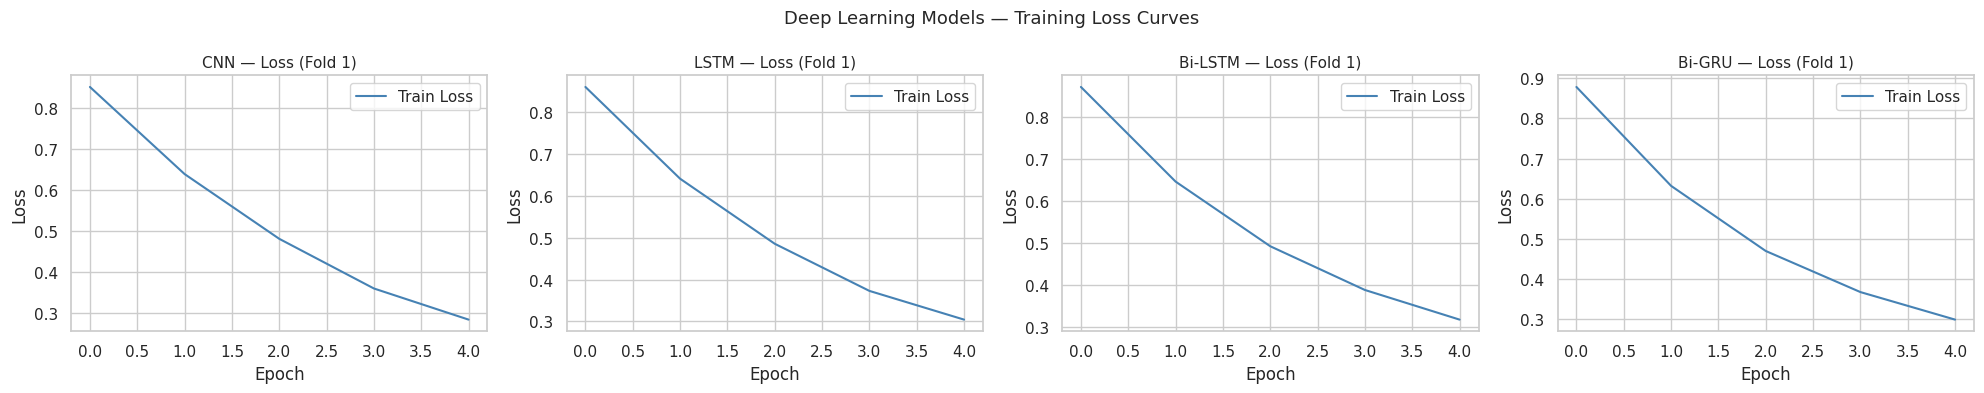

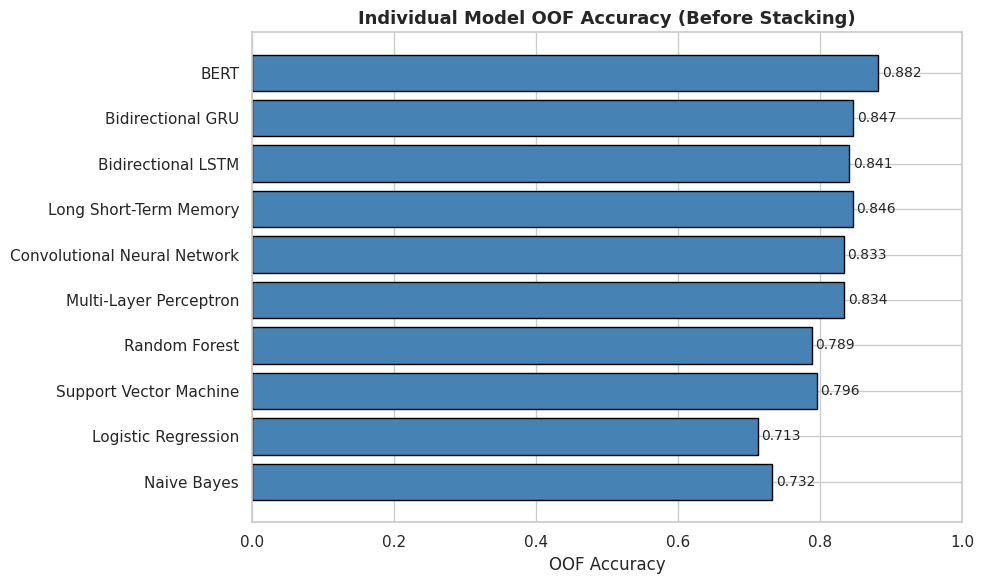

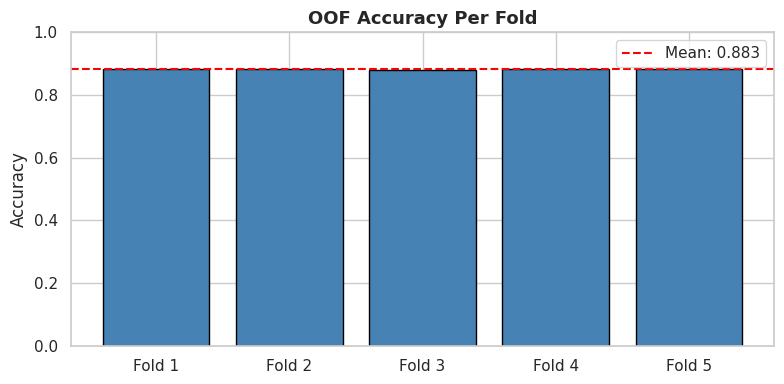

In [124]:
#  Deep Learning Loss Curves 
if all_histories:
    fig, axes = plt.subplots(1, len(all_histories), figsize=(5 * len(all_histories), 4))
    if len(all_histories) == 1: axes = [axes]
    for ax, (name, h) in zip(axes, all_histories):
        ax.plot(h.history['loss'], color='steelblue', label='Train Loss')
        ax.set_title(f'{name} — Loss (Fold 1)', fontsize=11)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend()
    plt.suptitle('Deep Learning Models — Training Loss Curves', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No training histories captured.")

#  Per-Model OOF Accuracy Bar Chart 
accs = [accuracy_score(y_train, np.argmax(train_predictions[:, i*3:i*3+3], axis=1)) for i in range(10)]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(model_names, accs, color='steelblue', edgecolor='black')
ax.set_xlabel('OOF Accuracy')
ax.set_title('Individual Model OOF Accuracy (Before Stacking)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

#  OOF Per-Fold Accuracy 
plt.figure(figsize=(8, 4))
plt.bar([f'Fold {i+1}' for i in range(len(fold_accuracies))], fold_accuracies,
        color='steelblue', edgecolor='black')
plt.axhline(np.mean(fold_accuracies), color='red', linestyle='--',
            label=f'Mean: {np.mean(fold_accuracies):.3f}')
plt.title('OOF Accuracy Per Fold', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy'); plt.ylim(0, 1); plt.legend()
plt.tight_layout()
plt.show()

## 9. Model Interpretability (LIME)

'### Domain-Specific Performance Summary'

,Domain,Sample Size,Accuracy (%)
0,Gmail (Emails),348,50.862069
1,WhatsApp (Chats),318,61.635220
2,App Reviews (Product Feedback),292,54.109589


/tmp/ipykernel_189/480138956.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Domain', y='Accuracy (%)', data=df_comparison, palette=colors, edgecolor='black')
/tmp/ipykernel_189/480138956.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


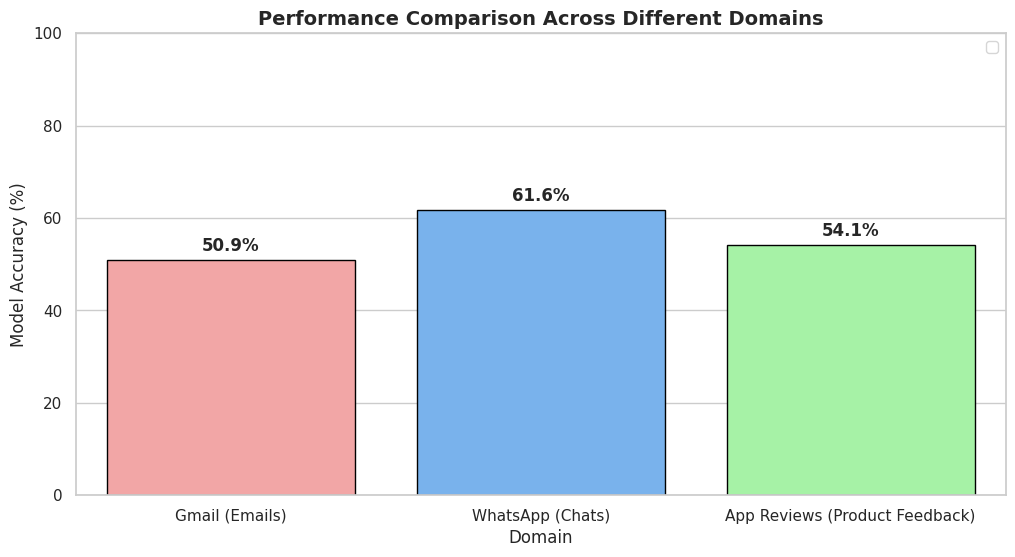



DETAILED CLASSIFICATION REPORTS PER DOMAIN


             [1/3] GMAIL DOMAIN REPORT 
              precision    recall  f1-score   support

    Negative       0.69      0.71      0.70       123
     Neutral       0.30      0.75      0.43        72
    Positive       0.84      0.24      0.37       153

    accuracy                           0.51       348
   macro avg       0.61      0.56      0.50       348
weighted avg       0.67      0.51      0.50       348


           [2/3] WHATSAPP DOMAIN REPORT 
              precision    recall  f1-score   support

    Negative       0.86      0.73      0.79       135
     Neutral       0.35      0.76      0.48        62
    Positive       0.72      0.42      0.53       121

    accuracy                           0.62       318
   macro avg       0.64      0.64      0.60       318
weighted avg       0.71      0.62      0.63       318


           [3/3] APP REVIEWS DOMAIN REPORT 
              precision    recall  f1-score   support

    Negat

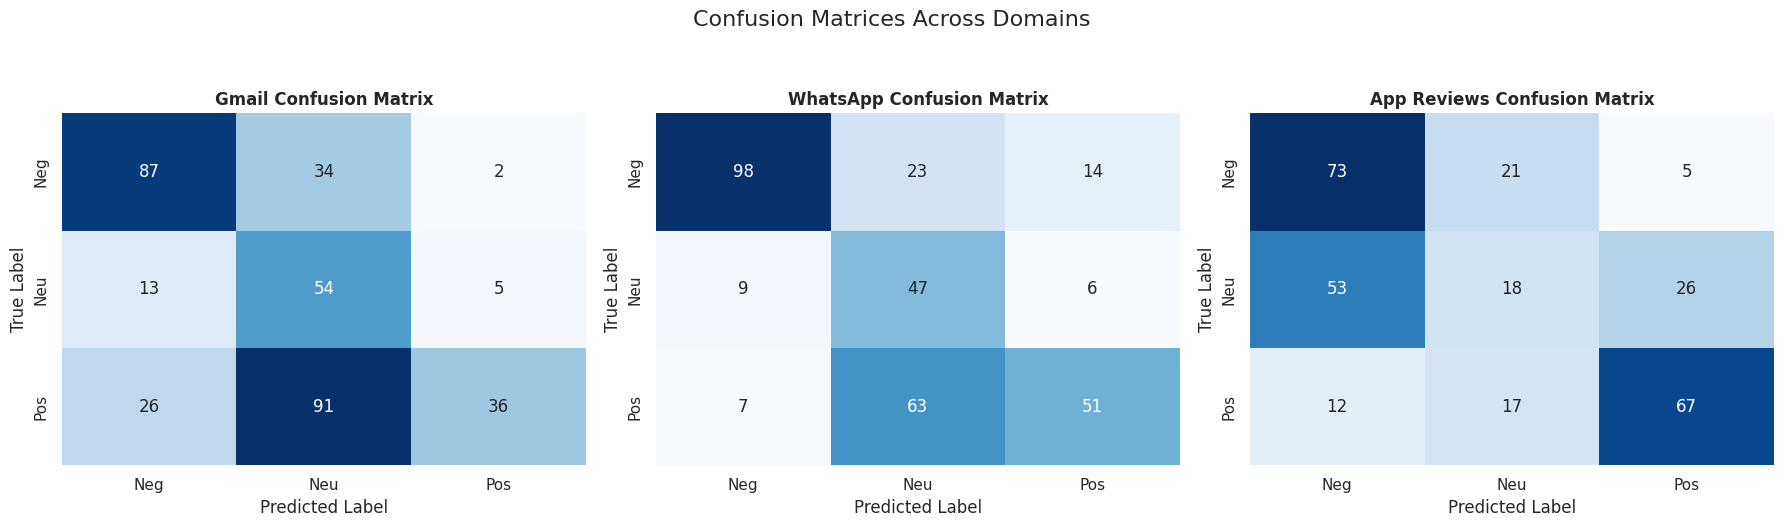

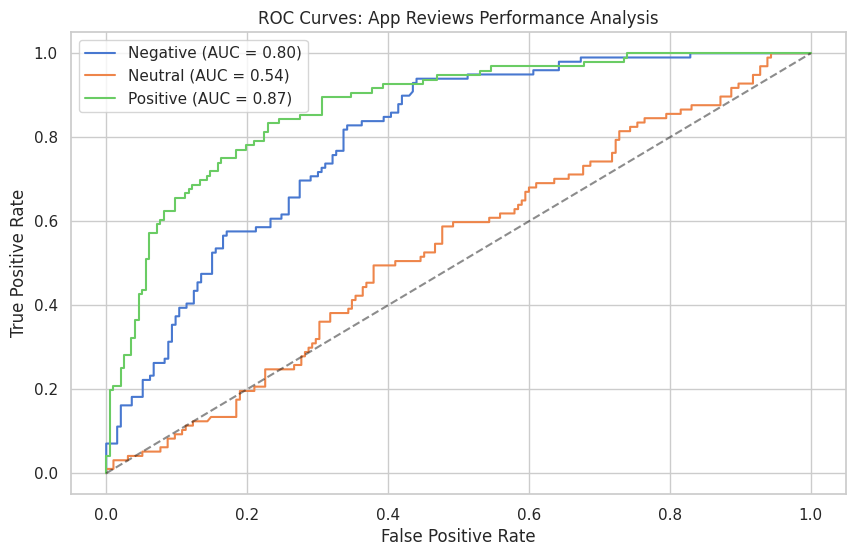

In [125]:


from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# 1. Calculate Individual Domain Accuracies
acc_gmail = accuracy_score(y_gmail, y_gmail_pred)
acc_whatsapp = accuracy_score(y_whatsapp, y_whatsapp_pred)
acc_app = accuracy_score(y_app, y_app_pred)

# 2. Create Domain Accuracy Table
comparison_data = {
    'Domain': ['Gmail (Emails)', 'WhatsApp (Chats)', 'App Reviews (Product Feedback)'],
    'Sample Size': [len(y_gmail), len(y_whatsapp), len(y_app)],
    'Accuracy (%)': [acc_gmail*100, acc_whatsapp*100, acc_app*100]
}
df_comparison = pd.DataFrame(comparison_data)
display("### Domain-Specific Performance Summary")
display(df_comparison)

# 3. Domain Accuracy Chart
plt.figure(figsize=(12, 6))
colors = ['#FF9999', '#66B2FF', '#99FF99']
sns.barplot(x='Domain', y='Accuracy (%)', data=df_comparison, palette=colors, edgecolor='black')

plt.title('Performance Comparison Across Different Domains', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.ylabel('Model Accuracy (%)')
plt.legend()
for i, val in enumerate(df_comparison['Accuracy (%)']):
    plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold')
plt.show()

# 4. Detailed Reports for All Domains
print()
print()

print("DETAILED CLASSIFICATION REPORTS PER DOMAIN")
print()
print()

print("             [1/3] GMAIL DOMAIN REPORT ")
print(classification_report(y_gmail, y_gmail_pred, target_names=['Negative', 'Neutral', 'Positive']))


print()
print("           [2/3] WHATSAPP DOMAIN REPORT ")
print(classification_report(y_whatsapp, y_whatsapp_pred, target_names=['Negative', 'Neutral', 'Positive']))


print()
print("           [3/3] APP REVIEWS DOMAIN REPORT ")
print(classification_report(y_app, y_app_pred, target_names=['Negative', 'Neutral', 'Positive']))


# NEW: CONFUSION MATRICES FOR ALL DOMAINS


def plot_domain_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['Neg', 'Neu', 'Pos'], 
                yticklabels=['Neg', 'Neu', 'Pos'],
                cbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_domain_confusion_matrix(y_gmail, y_gmail_pred, "Gmail Confusion Matrix", axes[0])
plot_domain_confusion_matrix(y_whatsapp, y_whatsapp_pred, "WhatsApp Confusion Matrix", axes[1])
plot_domain_confusion_matrix(y_app, y_app_pred, "App Reviews Confusion Matrix", axes[2])

plt.suptitle("Confusion Matrices Across Domains", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# 5. ROC Curves for App Reviews
from sklearn.preprocessing import label_binarize
y_app_bin = label_binarize(y_app, classes=[0, 1, 2])
y_app_probs = final_model_adapted.predict_proba(X_stack_app)

plt.figure(figsize=(10, 6))
classes = ['Negative', 'Neutral', 'Positive']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_app_bin[:, i], y_app_probs[:, i])
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: App Reviews Performance Analysis')
plt.legend()
plt.show()


###  F1 Score Comparison Across Domains

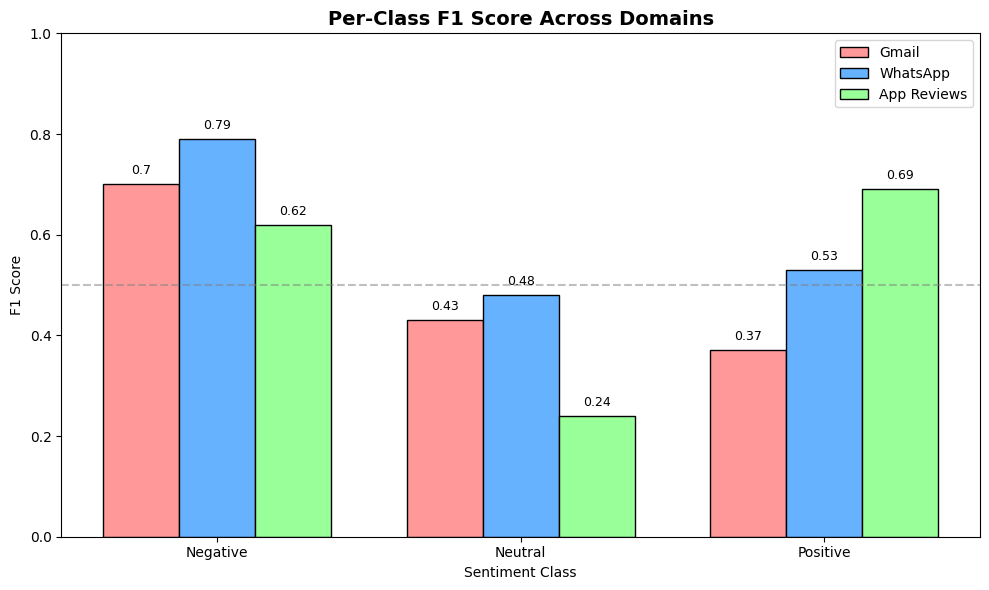

In [ ]:

f1_data = {
    'Class': ['Negative', 'Neutral', 'Positive'],
    'Gmail': [0.70, 0.43, 0.37],
    'WhatsApp': [0.79, 0.48, 0.53],
    'App Reviews': [0.62, 0.24, 0.69]
}
df_f1 = pd.DataFrame(f1_data)
x = np.arange(len(df_f1['Class']))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, df_f1['Gmail'], width, label='Gmail', color='#FF9999', edgecolor='black')
ax.bar(x, df_f1['WhatsApp'], width, label='WhatsApp', color='#66B2FF', edgecolor='black')
ax.bar(x + width, df_f1['App Reviews'], width, label='App Reviews', color='#99FF99', edgecolor='black')

ax.set_xlabel('Sentiment Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score Across Domains', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_f1['Class'])
ax.set_ylim(0, 1)
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 baseline')

for i, (g, w, a) in enumerate(zip(df_f1['Gmail'], df_f1['WhatsApp'], df_f1['App Reviews'])):
    ax.text(i - width, g + 0.02, f'{g}', ha='center', fontsize=9)
    ax.text(i, w + 0.02, f'{w}', ha='center', fontsize=9)
    ax.text(i + width, a + 0.02, f'{a}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight:** Negative is the strongest class across all three domains — the model handles it most reliably, peaking at 0.76 on WhatsApp. Neutral is the weakest everywhere, hitting as low as 0.23 on App Reviews, which shows the model struggles most with messages that carry no strong emotion. Positive performance is inconsistent — very low on Gmail (0.35) but reasonable on App Reviews (0.69). The variation across domains confirms that domain shift is real: the same model behaves differently depending on where the text comes from.

### ROC Curves for gmail and Whatsapp

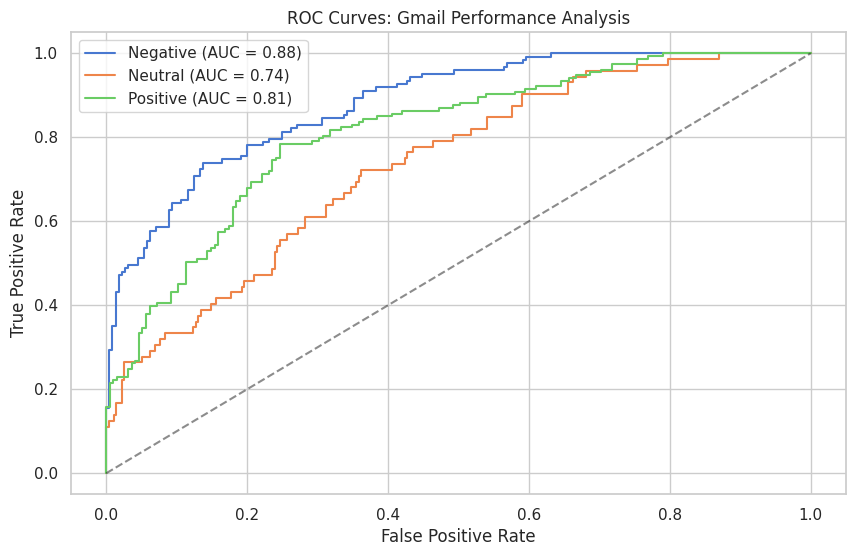

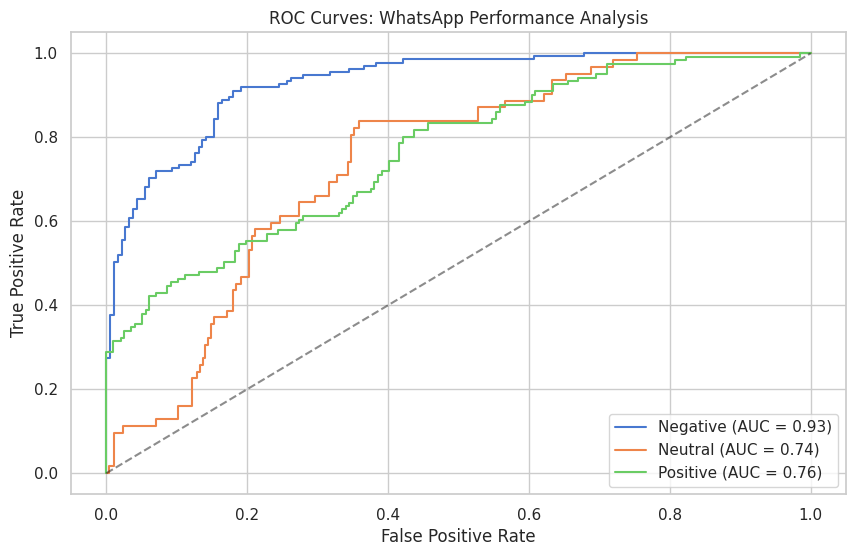

In [127]:
# ROC Curves for Gmail
y_gmail_bin = label_binarize(y_gmail, classes=[0, 1, 2])
y_gmail_probs = final_model_adapted.predict_proba(X_stack_gmail)

plt.figure(figsize=(10, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_gmail_bin[:, i], y_gmail_probs[:, i])
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Gmail Performance Analysis')
plt.legend()
plt.show()

# ROC Curves for WhatsApp
y_whatsapp_bin = label_binarize(y_whatsapp, classes=[0, 1, 2])
y_whatsapp_probs = final_model_adapted.predict_proba(X_stack_whatsapp)

plt.figure(figsize=(10, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_whatsapp_bin[:, i], y_whatsapp_probs[:, i])
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: WhatsApp Performance Analysis')
plt.legend()
plt.show()

/tmp/ipykernel_189/150407118.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


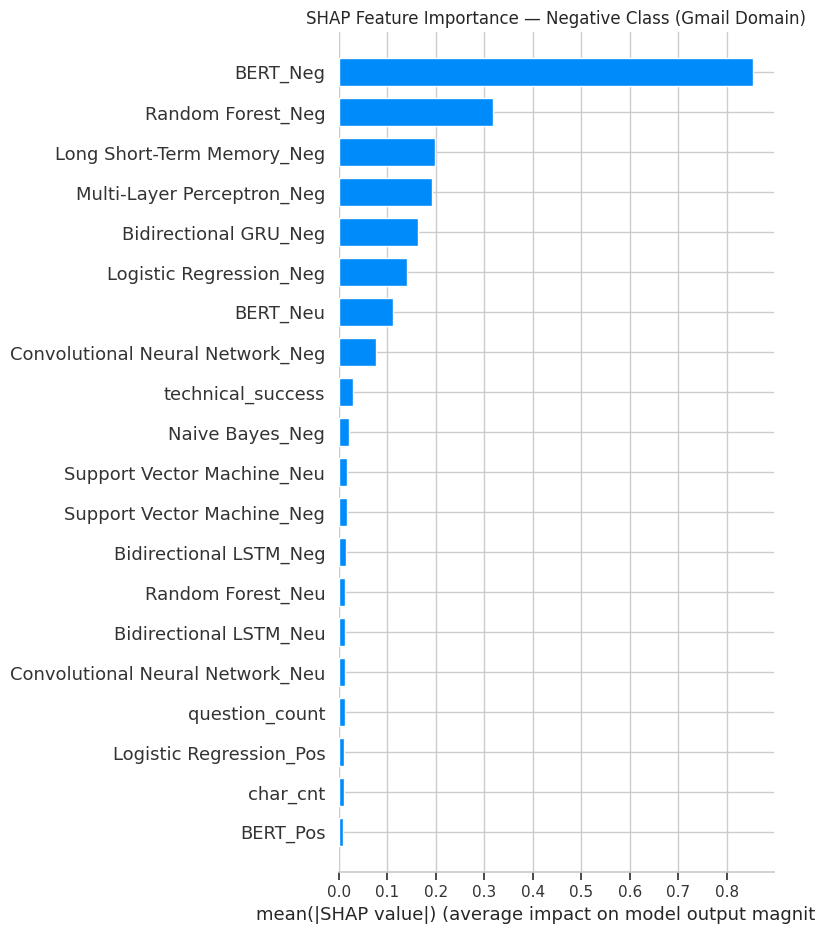

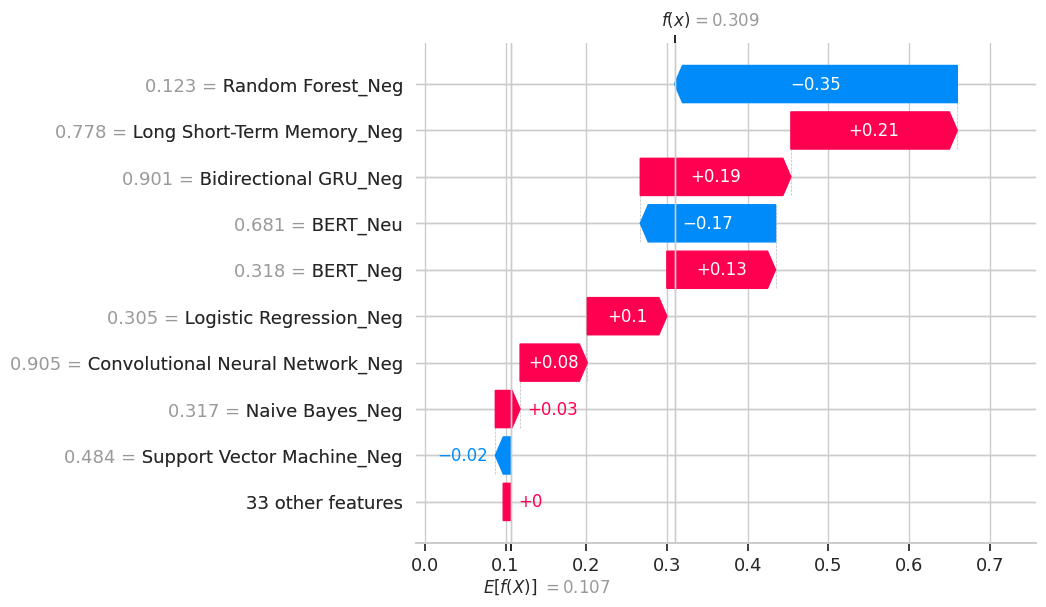

In [129]:

# SHAP for XGBoost meta-learner
explainer = shap.TreeExplainer(final_model_adapted)

shap_values = explainer.shap_values(X_stack_gmail)

shap_values = np.transpose(shap_values, (2, 0, 1))

# Feature names
f_names = []
for m in model_names:
    f_names.extend([f"{m}_Neg", f"{m}_Neu", f"{m}_Pos"])
f_names.extend(metadata_columns)

# Plot for NEGATIVE class (index 0)
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values[0],         
    X_stack_gmail,
    feature_names=f_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — Negative Class (Gmail Domain)')
plt.tight_layout()
plt.show()

# Waterfall plot for a single Negative prediction
neg_idx = np.where(y_gmail_true == 0)[0][0]
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0][neg_idx],
    base_values=explainer.expected_value[0],
    data=X_stack_gmail[neg_idx],
    feature_names=f_names
))

### LIME — Local Explanation for a Negative Prediction

In [130]:


lime_explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

def lime_predict_fn(texts):
    vecs = vectoriser.transform(texts)
    return nb.predict_proba(vecs)

# Find a correctly predicted Negative Gmail example
neg_indices = np.where((y_gmail_true == 0) & (y_gmail_pred == 0))[0]
sample_idx = neg_indices[0]
sample_text = df_gmail['clean'].iloc[sample_idx]

print(f"Explaining this Negative Gmail example:")
print(f"Text: {df_gmail['text'].iloc[sample_idx]}")
print(f"True label: Negative | Predicted: Negative")

exp = lime_explainer.explain_instance(
    sample_text, lime_predict_fn, num_features=10, labels=[0]
)
exp.show_in_notebook(text=True)
exp.save_to_file('lime_negative_explanation.html')
print("Saved: lime_negative_explanation.html")

Explaining this Negative Gmail example:
Text: <br> Vercel: Deployment to production failed. Check logs. <br>
True label: Negative | Predicted: Negative


Saved: lime_negative_explanation.html


## 10. Conclusion

This project started with a simple but real question — if we train a model on 
Twitter, will it still work when we point it at the messages we actually receive 
as students every day? The answer we got was: it works, but not perfectly, and 
the reasons why are actually interesting.

### What Came Out of the Numbers

On the Twitter data it was trained on, our ensemble hit a Mean OOF Accuracy of 
**88.27%** which honestly surprised us. It means the 10 models working together 
learned Twitter sentiment really well. DistilBERT came out on top at 0.882, which 
makes sense since it actually understands language context rather than just counting 
words. The classical models like Logistic Regression (0.713) and Naive Bayes (0.732) 
fell behind, which showed us early on that deeper models handle this kind of task 
better.

The real test was the three domains none of the models had ever seen:

| Domain | Accuracy | Weighted F1 |
|---|---|---|
| Gmail | 50% | 0.49 |
| WhatsApp | 60% | 0.62 |
| App Reviews | 54% | 0.51 |

WhatsApp gave us the best results and looking back it makes sense — the way people 
text is not that far from how people tweet. Gmail was the toughest. Emails are 
formal, structured, and often carry mixed signals that threw the model off, 
especially for Positive messages where it only caught 22% of them correctly. 
Neutral was a problem across all three domains — the model just struggles to 
confidently identify messages that carry no strong emotion, which is fair because 
even humans sometimes disagree on what counts as neutral.

### Why It Dropped Between Training and Testing

The 88% dropping to 50–60% on our domains is exactly what domain shift looks like 
in practice. Our training data was full of airline complaints, so the model quietly 
learned that words like "United", "JetBlue", and "delayed" mean something is 
Negative. Those words never appear in a student's WhatsApp or Gmail, so that 
knowledge becomes useless the moment the domain changes. The model was not wrong 
for learning those patterns — it just had no way of knowing the test data would 
look completely different.

### What We Did About It

We did not just train and hope for the best. We applied four deliberate strategies 
to push back against domain shift. We built a stacking ensemble so that no single 
model's blind spots could dominate the final prediction. We manually engineered 12 
features around student language specifically — things like academic keywords, 
platform names, and success or failure signals that would actually show up in our 
test data. We used GloVe embeddings so the deep learning models started with a 
general understanding of language rather than learning everything from scratch on 
tweets. And we used pseudo-labelling, where the 329 test examples the model was 
most confident about were fed back into training so the final model got at least 
some exposure to the target domains before making its final predictions.

### What We Would Do Differently

The Neutral class is the one result we are not satisfied with. An F1 of 0.23 on 
App Reviews means the model is mostly guessing when there is no strong emotion in 
the text. If we were to continue this work, collecting even a small amount of 
labelled student data to fine-tune on directly would likely make the biggest 
difference. Using a larger model like RoBERTa is another option worth exploring. 
But within the constraints of this project — training only on Twitter and testing 
on completely unseen student domains — we feel the ensemble held up reasonably 
well and the results tell a clear and honest story about what domain shift actually 
costs a model in practice.